In [1]:
from pathlib import Path
import pandas as pd

In [2]:
def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Tagesschau"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()
print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")
df.head()


Loaded 6320 rows from 2 file(s) in /Users/MattisHaumann/Dev/Thesis/data/raw/Alternative Medien/Tagesschau


,sophoraId,externalId,title,date,tags,updateCheckUrl,content,tracking,topline,firstSentence,...,teaserImage.type,teaserImage.title,comments,brandingImage.title,brandingImage.copyright,brandingImage.alttext,brandingImage.imageVariants.original,brandingImage.type,source,source_file
0,afghanistan-flieger-pakistan-100,6463c06f-784f-4813-b7e2-d0fc2070c6fa,Deutschland holt zehn afghanische Familien aus...,2025-09-01T09:00:06.043+02:00,"[{'tag': 'Afghanistan'}, {'tag': 'Menschenrech...",https://www.tagesschau.de/api2u/afghanistan-fl...,[{'value': '<strong>Zehn afghanische Familien ...,[{'sid': 'app.ausland.afghanistan-flieger-paki...,Flieger auf dem Weg nach Hannover,Zehn afghanische Familien dürfen aus Pakistan ...,...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv
1,afghanistan-internet-104,80ab56f5-16bd-4343-994d-c202745c3362,Afghanistan ist wieder online,2025-10-01T18:30:21.655+02:00,"[{'tag': 'Afghanistan'}, {'tag': 'Internet'}]",https://www.tagesschau.de/api2u/afghanistan-in...,[{'value': '<strong>Handys und Internet funkti...,[{'sid': 'app.ausland.afghanistan-internet-104...,Nach Chaos im Land,Die Taliban begründeten den Ausfall mit techni...,...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv
2,aethiopien-deutsche-welle-korrespondenten-100,333b0442-121b-42f7-9395-379d426bbef2,Äthiopien suspendiert Deutsche-Welle-Journalisten,2025-10-24T19:37:10.246+02:00,"[{'tag': 'Äthiopien'}, {'tag': 'Deutsche Welle'}]",https://www.tagesschau.de/api2u/aethiopien-deu...,[{'value': '<strong>Die Deutsche Welle darf vo...,[{'sid': 'app.ausland.afrika.aethiopien-deutsc...,Medienbehörde EMA,Die Deutsche Welle darf vorerst nicht mehr dir...,...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv
3,aethiopien-kirche-einsturz-100,7cd86ce3-d711-42c7-9006-020ef1a7a713,Mindestens 30 Tote bei Einsturz von Baugerüst,2025-10-02T02:18:37.979+02:00,"[{'tag': 'Äthiopien'}, {'tag': 'Kirche'}, {'ta...",https://www.tagesschau.de/api2u/aethiopien-kir...,[{'value': '<strong>Viele Menschen befanden si...,[{'sid': 'app.ausland.afrika.aethiopien-kirche...,Äthiopien,"Obwohl die Kirche renoviert wurde, hatten sich...",...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv
4,agoa-usa-afrika-100,5068ef2d-48ce-4004-a227-48849a4c5e4b,Brechen afrikanische Exporte in die USA ein?,2025-09-30T15:28:43.132+02:00,"[{'tag': 'AGOA'}, {'tag': 'Afrika'}, {'tag': '...",https://www.tagesschau.de/api2u/agoa-usa-afrik...,[{'value': '<strong>Seit Jahrzehnten verkaufen...,[{'sid': 'app.ausland.afrika.agoa-usa-afrika-1...,Aus für Handelsabkommen AGOA,Seit Jahrzehnten verkaufen mehr als die Hälfte...,...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv


In [3]:
print(df.shape)


(6320, 44)


In [4]:
df["source"] = "Tagesschau"
df[["source"]].head()

,source
0,Tagesschau
1,Tagesschau
2,Tagesschau
3,Tagesschau
4,Tagesschau


## Cleaning Tagesschau

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6320 entries, 0 to 6319
Data columns (total 44 columns):
 #   Column                                Non-Null Count  Dtype
---  ------                                --------------  -----
 0   sophoraId                             6320 non-null   str  
 1   externalId                            6320 non-null   str  
 2   title                                 6320 non-null   str  
 3   date                                  6320 non-null   str  
 4   tags                                  6320 non-null   str  
 5   updateCheckUrl                        6320 non-null   str  
 6   content                               6320 non-null   str  
 7   tracking                              6320 non-null   str  
 8   topline                               6320 non-null   str  
 9   firstSentence                         6320 non-null   str  
 10  images                                6320 non-null   str  
 11  details                               6320 non-null   

In [6]:
pd.set_option("display.max_rows", None)
df.head()

,sophoraId,externalId,title,date,tags,updateCheckUrl,content,tracking,topline,firstSentence,...,teaserImage.type,teaserImage.title,comments,brandingImage.title,brandingImage.copyright,brandingImage.alttext,brandingImage.imageVariants.original,brandingImage.type,source,source_file
0,afghanistan-flieger-pakistan-100,6463c06f-784f-4813-b7e2-d0fc2070c6fa,Deutschland holt zehn afghanische Familien aus...,2025-09-01T09:00:06.043+02:00,"[{'tag': 'Afghanistan'}, {'tag': 'Menschenrech...",https://www.tagesschau.de/api2u/afghanistan-fl...,[{'value': '<strong>Zehn afghanische Familien ...,[{'sid': 'app.ausland.afghanistan-flieger-paki...,Flieger auf dem Weg nach Hannover,Zehn afghanische Familien dürfen aus Pakistan ...,...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv
1,afghanistan-internet-104,80ab56f5-16bd-4343-994d-c202745c3362,Afghanistan ist wieder online,2025-10-01T18:30:21.655+02:00,"[{'tag': 'Afghanistan'}, {'tag': 'Internet'}]",https://www.tagesschau.de/api2u/afghanistan-in...,[{'value': '<strong>Handys und Internet funkti...,[{'sid': 'app.ausland.afghanistan-internet-104...,Nach Chaos im Land,Die Taliban begründeten den Ausfall mit techni...,...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv
2,aethiopien-deutsche-welle-korrespondenten-100,333b0442-121b-42f7-9395-379d426bbef2,Äthiopien suspendiert Deutsche-Welle-Journalisten,2025-10-24T19:37:10.246+02:00,"[{'tag': 'Äthiopien'}, {'tag': 'Deutsche Welle'}]",https://www.tagesschau.de/api2u/aethiopien-deu...,[{'value': '<strong>Die Deutsche Welle darf vo...,[{'sid': 'app.ausland.afrika.aethiopien-deutsc...,Medienbehörde EMA,Die Deutsche Welle darf vorerst nicht mehr dir...,...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv
3,aethiopien-kirche-einsturz-100,7cd86ce3-d711-42c7-9006-020ef1a7a713,Mindestens 30 Tote bei Einsturz von Baugerüst,2025-10-02T02:18:37.979+02:00,"[{'tag': 'Äthiopien'}, {'tag': 'Kirche'}, {'ta...",https://www.tagesschau.de/api2u/aethiopien-kir...,[{'value': '<strong>Viele Menschen befanden si...,[{'sid': 'app.ausland.afrika.aethiopien-kirche...,Äthiopien,"Obwohl die Kirche renoviert wurde, hatten sich...",...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv
4,agoa-usa-afrika-100,5068ef2d-48ce-4004-a227-48849a4c5e4b,Brechen afrikanische Exporte in die USA ein?,2025-09-30T15:28:43.132+02:00,"[{'tag': 'AGOA'}, {'tag': 'Afrika'}, {'tag': '...",https://www.tagesschau.de/api2u/agoa-usa-afrik...,[{'value': '<strong>Seit Jahrzehnten verkaufen...,[{'sid': 'app.ausland.afrika.agoa-usa-afrika-1...,Aus für Handelsabkommen AGOA,Seit Jahrzehnten verkaufen mehr als die Hälfte...,...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv


In [7]:
df.rename(columns={"updateCheckUrl": "URL"}, inplace=True)

In [8]:
cols_to_keep = [
    "title",
    "date",
    "tags",
    "URL",
    "content",
    "topline",
    "ressort",
    "regionId",
    "type"]


df_clean = df.loc[:, cols_to_keep].copy()

In [9]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 6320 entries, 0 to 6319
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   title     6320 non-null   str  
 1   date      6320 non-null   str  
 2   tags      6320 non-null   str  
 3   URL       6320 non-null   str  
 4   content   6320 non-null   str  
 5   topline   6320 non-null   str  
 6   ressort   5938 non-null   str  
 7   regionId  6320 non-null   int64
 8   type      6320 non-null   str  
dtypes: int64(1), str(8)
memory usage: 444.5 KB


In [10]:
print("Non-null content rows:", df_clean["content"].notna().sum())

# 2) Show a few example rows (full text, no truncation)
sample_idx = (
    df_clean["content"]
    .dropna()
    .sample(n=min(5, df_clean["content"].dropna().shape[0]), random_state=42)
    .index
)


display(df_clean.loc[sample_idx, ["title", "date", "content"]])

# 3) Also inspect edge cases: shortest and longest content
tmp = df_clean.loc[df_clean["content"].notna(), ["title", "date", "content"]].copy()
tmp["content_len"] = tmp["content"].str.len()


display(tmp.nsmallest(2, "content_len")[["title", "date", "content", "content_len"]])
display(tmp.nlargest(2, "content_len")[["title", "date", "content", "content_len"]])


Non-null content rows: 6320


,title,date,content
4083,Huawei und ZTE sollen raus aus dem Netz,2026-01-20T16:51:12.910+01:00,[{'value': '<strong>Die EU-Kommission will die...
3844,Mindestens 30 Verletzte durch Erdbeben in Japan,2025-12-09T08:41:13.658+01:00,[{'value': '<strong>Regierungschefin Takaichi ...
712,Oppositionspolitiker in der Türkei festgenommen,2025-09-13T14:51:47.491+02:00,[{'value': '<strong>Die Istanbuler Staatsanwal...
3649,Will Trump das Erdöl?,2025-12-12T07:44:58.890+01:00,[{'value': '<strong>Die Beschlagnahmung des Ta...
2873,Junge Leser retten die Buchbranche,2025-10-15T12:46:58.432+02:00,[{'value': '<strong>Das Interesse an Büchern s...


,title,date,content,content_len
2277,"Müll in Parks, teure Autobahn, Taylor Swifts V...",2025-08-28T06:52:40.604+02:00,[],2
5525,"Verbrenner, Werkstätten für behinderte Mensche...",2025-12-17T08:25:23.264+01:00,[{'value': '<em>tagesschau.de | Podcast 15 Min...,166


,title,date,content,content_len
2278,++ US-Gipfelunterlagen in Hotel-Drucker gefund...,2025-08-16T23:57:01.026+02:00,[{'value': '<strong>In einem Hotel-Drucker in ...,192083
2318,"++ ""Palästinenser müssen sich von Hamas lossag...",2025-10-13T23:00:59.763+02:00,[{'value': '<strong>Außenminister Wadephul for...,164376


In [11]:
import ast
import html
import re
import pandas as pd

TEXT_TYPES = {"text", "headline"}

def _clean_html(s: str) -> str:
    if not s:
        return ""
    s = html.unescape(s)
    s = re.sub(r"<a\b[^>]*>(.*?)</a>", r"\1", s, flags=re.IGNORECASE | re.DOTALL)  # keep anchor text, remove link
    s = re.sub(r"<[^>]+>", " ", s)                                                   # remove remaining tags
    s = re.sub(r"\s+", " ", s).strip()
    return s

def extract_content_text(content_raw: str) -> str:
    if pd.isna(content_raw):
        return ""
    try:
        blocks = ast.literal_eval(content_raw) if isinstance(content_raw, str) else content_raw
    except Exception:
        return _clean_html(str(content_raw))

    if not isinstance(blocks, list):
        return _clean_html(str(blocks))

    out = []
    for b in blocks:
        if not isinstance(b, dict):
            continue
        btype = b.get("type")
        if btype in TEXT_TYPES and "value" in b:
            txt = _clean_html(str(b["value"]))
            if txt:
                if btype == "headline":
                    out.append(f"\n{txt}\n")  # keep section structure
                else:
                    out.append(txt)

    return "\n".join(x for x in out if x).strip()

df_clean["content_clean"] = df_clean["content"].apply(extract_content_text)

In [12]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 6320 entries, 0 to 6319
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   title          6320 non-null   str  
 1   date           6320 non-null   str  
 2   tags           6320 non-null   str  
 3   URL            6320 non-null   str  
 4   content        6320 non-null   str  
 5   topline        6320 non-null   str  
 6   ressort        5938 non-null   str  
 7   regionId       6320 non-null   int64
 8   type           6320 non-null   str  
 9   content_clean  6320 non-null   str  
dtypes: int64(1), str(9)
memory usage: 493.9 KB


In [13]:
df_clean = df_clean.rename(
    columns={
        "date": "Date",
        "content_clean": "Text",
        "title": "Title",
    }
)

In [14]:
dates = (
    pd.to_datetime(df_clean["Date"], errors="coerce", utc=True)
      .dt.tz_convert("Europe/Berlin")
)

start = pd.Timestamp("2025-08-01", tz="Europe/Berlin")
end_exclusive = pd.Timestamp("2026-02-01", tz="Europe/Berlin")  # includes full Jan 31

mask = (dates >= start) & (dates < end_exclusive)

df_clean = df_clean.loc[mask].copy()
df_clean["Date"] = dates.loc[mask]

print(f"Rows in selected period: {len(df_clean)}")
df_clean.sort_values("Date").head()


Rows in selected period: 6320


,Title,Date,tags,URL,content,topline,ressort,regionId,type,Text
1493,Noch eine Generalsanierung - muss das sein?,2025-08-01 05:38:57.531000+02:00,"[{'tag': 'Bahn'}, {'tag': 'Generalsanierung'}]",https://www.tagesschau.de/api2u/generalsanieru...,[{'value': '<strong>Bei der Bahn steht die näc...,Bahnstrecke Hamburg-Berlin,inland,0,story,Bei der Bahn steht die nächste Generalsanierun...
904,"Überwachen, durchsuchen, isolieren",2025-08-01 06:07:21.349000+02:00,"[{'tag': 'Frankreich'}, {'tag': 'Drogenhandel'...",https://www.tagesschau.de/api2u/frankreich-str...,[{'value': '<strong>Im Kampf gegen den Drogenh...,Frankreichs neue Härte gegen Drogenhändler,ausland,0,story,Im Kampf gegen den Drogenhandel setzt Frankrei...
2146,Extremisten besitzen Tausende legale Schusswaffen,2025-08-01 06:08:03.367000+02:00,[{'tag': 'Waffenbesitz'}],https://www.tagesschau.de/api2u/waffenbesitz-l...,[{'value': '<strong>Im Zuge eines Aktionsplans...,Waffenbesitz in Deutschland,investigativ,0,story,Im Zuge eines Aktionsplans wollte die ehemalig...
3168,Klimawandel erlebbar machen,2025-08-01 06:11:46.342000+02:00,"[{'tag': 'Klimawandel'}, {'tag': 'App'}, {'tag...",https://www.tagesschau.de/api2u/klimawandel-ap...,[{'value': '<strong>Wie viel kühler wäre die I...,Stadt im Wandel,wissen,0,story,"Wie viel kühler wäre die Innenstadt, wenn mehr..."
2399,Welche Rechte und Pflichten Azubis haben,2025-08-01 06:13:42.673000+02:00,"[{'tag': 'Azubis'}, {'tag': 'Ausbildung'}, {'t...",https://www.tagesschau.de/api2u/auszubildende-...,[{'value': '<strong>Wie viel Geld verdiene ich...,Start des Ausbildungsjahres,wirtschaft,0,story,Wie viel Geld verdiene ich in meiner Ausbildun...


In [15]:
# keep dtype as datetime64[ns]
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce").dt.normalize()


In [16]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 6320 entries, 0 to 6319
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype                        
---  ------    --------------  -----                        
 0   Title     6320 non-null   str                          
 1   Date      6320 non-null   datetime64[us, Europe/Berlin]
 2   tags      6320 non-null   str                          
 3   URL       6320 non-null   str                          
 4   content   6320 non-null   str                          
 5   topline   6320 non-null   str                          
 6   ressort   5938 non-null   str                          
 7   regionId  6320 non-null   int64                        
 8   type      6320 non-null   str                          
 9   Text      6320 non-null   str                          
dtypes: datetime64[us, Europe/Berlin](1), int64(1), str(8)
memory usage: 493.9 KB


In [17]:
df_clean.head()

,Title,Date,tags,URL,content,topline,ressort,regionId,type,Text
0,Deutschland holt zehn afghanische Familien aus...,2025-09-01 00:00:00+02:00,"[{'tag': 'Afghanistan'}, {'tag': 'Menschenrech...",https://www.tagesschau.de/api2u/afghanistan-fl...,[{'value': '<strong>Zehn afghanische Familien ...,Flieger auf dem Weg nach Hannover,ausland,0,story,Zehn afghanische Familien dürfen aus Pakistan ...
1,Afghanistan ist wieder online,2025-10-01 00:00:00+02:00,"[{'tag': 'Afghanistan'}, {'tag': 'Internet'}]",https://www.tagesschau.de/api2u/afghanistan-in...,[{'value': '<strong>Handys und Internet funkti...,Nach Chaos im Land,ausland,0,story,Handys und Internet funktionieren in Afghanist...
2,Äthiopien suspendiert Deutsche-Welle-Journalisten,2025-10-24 00:00:00+02:00,"[{'tag': 'Äthiopien'}, {'tag': 'Deutsche Welle'}]",https://www.tagesschau.de/api2u/aethiopien-deu...,[{'value': '<strong>Die Deutsche Welle darf vo...,Medienbehörde EMA,ausland,0,story,Die Deutsche Welle darf vorerst nicht mehr dir...
3,Mindestens 30 Tote bei Einsturz von Baugerüst,2025-10-02 00:00:00+02:00,"[{'tag': 'Äthiopien'}, {'tag': 'Kirche'}, {'ta...",https://www.tagesschau.de/api2u/aethiopien-kir...,[{'value': '<strong>Viele Menschen befanden si...,Äthiopien,ausland,0,story,Viele Menschen befanden sich in der Kirche der...
4,Brechen afrikanische Exporte in die USA ein?,2025-09-30 00:00:00+02:00,"[{'tag': 'AGOA'}, {'tag': 'Afrika'}, {'tag': '...",https://www.tagesschau.de/api2u/agoa-usa-afrik...,[{'value': '<strong>Seit Jahrzehnten verkaufen...,Aus für Handelsabkommen AGOA,ausland,0,story,Seit Jahrzehnten verkaufen mehr als die Hälfte...


In [18]:
df_clean["Date"].min()

Timestamp('2025-08-01 00:00:00+0200', tz='Europe/Berlin')

In [19]:
df_clean["Date"].max()

Timestamp('2026-01-31 00:00:00+0100', tz='Europe/Berlin')

In [20]:
df_clean["Text"] = (
    df_clean["Text"]
    .fillna("")
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

Date

In [21]:
df_clean["Date"].min(), df_clean["Date"].max()

(Timestamp('2025-08-01 00:00:00+0200', tz='Europe/Berlin'),
 Timestamp('2026-01-31 00:00:00+0100', tz='Europe/Berlin'))

## EDA

In [224]:
# Columns to check for duplicate records
dup_cols = ["Title"]

# Find duplicates (all rows that belong to duplicate groups)
dup_mask = df_clean.duplicated(subset=dup_cols, keep=False)
dups = df_clean.loc[dup_mask].sort_values(dup_cols)

print(f"Number of duplicate rows (across {dup_cols}): {len(dups)}")

# optional preview
dups.head()


Number of duplicate rows (across ['Title']): 8


,Title,Date,tags,URL,content,topline,ressort,regionId,type,Text
2617,EZB hält Zinsen erneut stabil,2025-09-11 00:00:00+02:00,"[{'tag': 'EZB'}, {'tag': 'Zinsen'}, {'tag': 'N...",https://www.tagesschau.de/api2u/ezb-zinsen-lag...,[{'value': '<strong>Die EZB hat die Leitzinsen...,Geldpolitik,wirtschaft,0,story,Die EZB hat die Leitzinsen in der Eurozone nic...
5811,EZB hält Zinsen erneut stabil,2025-12-18 00:00:00+01:00,"[{'tag': 'EZB'}, {'tag': 'Notenbank'}, {'tag':...",https://www.tagesschau.de/api2u/ezb-leitzins-n...,[{'value': '<strong>Die Europäische Zentralban...,Geldpolitik,wirtschaft,0,story,Die Europäische Zentralbank hat die Leitzinsen...
5170,SPD-Mitgliederbegehren nimmt erste Hürde,2025-12-22 00:00:00+01:00,"[{'tag': 'SPD'}, {'tag': 'Bürgergeld'}, {'tag'...",https://www.tagesschau.de/api2u/spd-mitglieder...,[{'value': '<strong>Die Gegner der Bürgergeldr...,Initiative gegen Bürgergeldreform,inland,0,story,Die Gegner der Bürgergeldreform in der SPD fah...
5296,SPD-Mitgliederbegehren nimmt erste Hürde,2025-11-26 00:00:00+01:00,"[{'tag': 'SPD'}, {'tag': 'Bürgergeld'}]",https://www.tagesschau.de/api2u/spd-mitglieder...,[{'value': '<strong>In der SPD hatten Gegner d...,Initiative gegen Bürgergeldreform,inland,0,story,In der SPD hatten Gegner der geplanten Bürgerg...
2574,US-Anleger werden vorsichtiger,2025-10-09 00:00:00+02:00,"[{'tag': 'Marktbericht'}, {'tag': 'Aktienmarkt...",https://www.tagesschau.de/api2u/marktbericht-g...,[{'value': '<strong>Zwar gab es heute im frühe...,Wall Street dreht ins Minus,wirtschaft,0,story,Zwar gab es heute im frühen Geschäft an der Wa...


In [225]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
articles_per_month = df_clean.groupby(df_clean['Date'].dt.to_period('M')).size().reset_index(name='article_count')
articles_per_month.columns = ['month', 'article_count']
articles_per_month

,month,article_count
0,2025-08,1082
1,2025-09,1074
2,2025-10,1088
3,2025-11,1088
4,2025-12,986
5,2026-01,1002


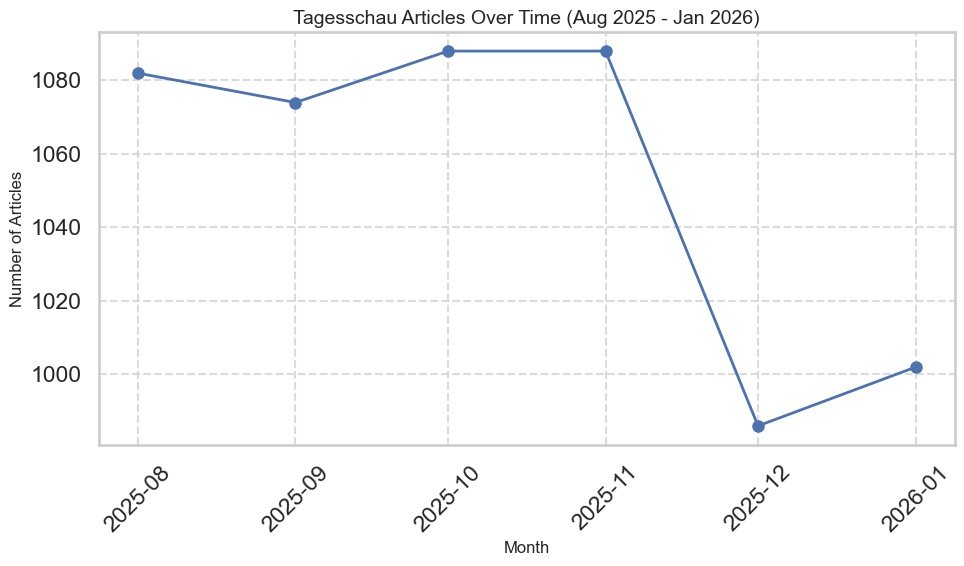

In [226]:
import matplotlib.pyplot as plt

# Create a time series plot of articles per month
fig, ax = plt.subplots(figsize=(10, 6))

# Convert period to timestamp for plotting
articles_per_month['month_ts'] = articles_per_month['month'].dt.to_timestamp()

ax.plot(articles_per_month['month_ts'], articles_per_month['article_count'], marker='o', linewidth=2, markersize=8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('Tagesschau Articles Over Time (Aug 2025 - Jan 2026)', fontsize=14)

plt.xticks(rotation=45)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


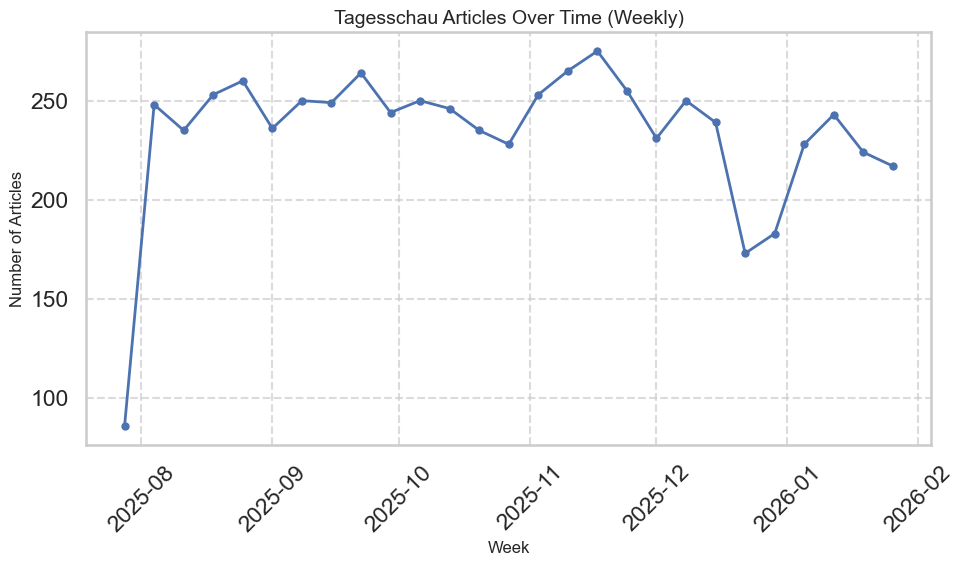

In [227]:
import matplotlib.pyplot as plt

# Create weekly counts
articles_per_week = (
    df_clean
    .groupby(df_clean['Date'].dt.to_period('W'))
    .size()
    .reset_index(name='article_count')
)
articles_per_week.columns = ['week', 'article_count']

# Convert period to timestamp for plotting
articles_per_week['week_ts'] = articles_per_week['week'].dt.to_timestamp()

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(articles_per_week['week_ts'], articles_per_week['article_count'], marker='o', linewidth=2, markersize=5)

ax.set_xlabel('Week', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('Tagesschau Articles Over Time (Weekly)', fontsize=14)

plt.xticks(rotation=45)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


NA count in 'ressort': 382


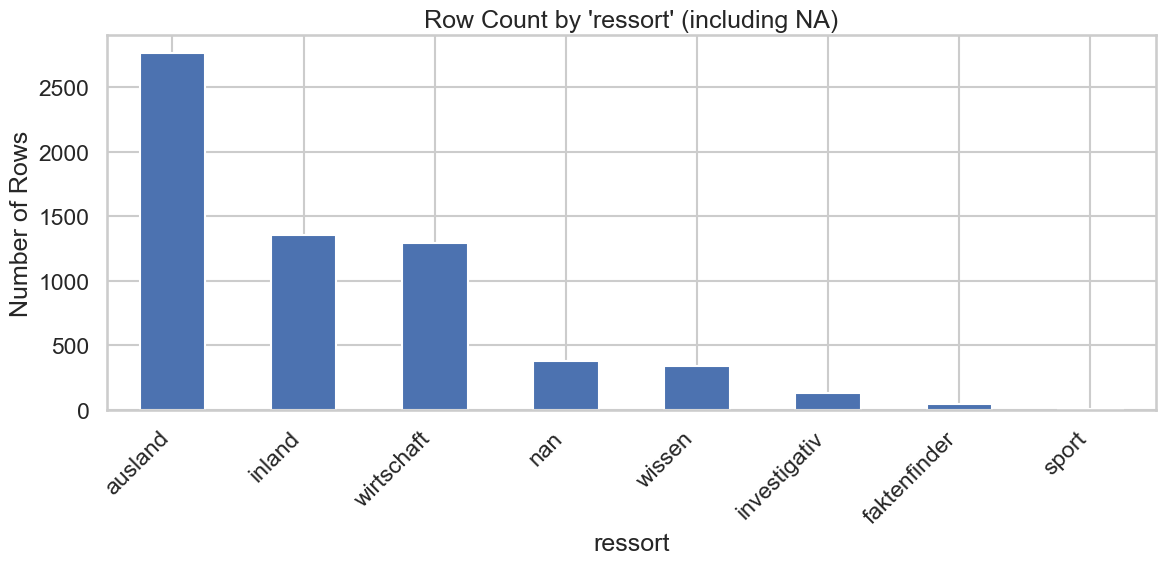

In [228]:
# Count values and NAs in ressort
ressort_counts = df_clean["ressort"].value_counts(dropna=False)
na_count = df_clean["ressort"].isna().sum()

print(f"NA count in 'ressort': {na_count}")

# Plot counts (including NA as category)
plot_counts = ressort_counts.copy()
plot_counts.index = plot_counts.index.astype(str)

plt.figure(figsize=(12, 6))
plot_counts.sort_values(ascending=False).plot(kind="bar")
plt.xlabel("ressort")
plt.ylabel("Number of Rows")
plt.title("Row Count by 'ressort' (including NA)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [229]:
df_clean["article_length_words"] = df_clean["Text"].str.split().str.len()
df_clean["article_length_chars"] = df_clean["Text"].str.len()

df_clean["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)


count    6320.0
mean      600.8
std       426.5
min         0.0
10%       284.0
25%       381.0
50%       523.5
75%       702.0
90%       916.0
95%      1099.0
99%      2500.8
max      8360.0
Name: article_length_words, dtype: float64

In [230]:
# Example article from "Wissen" and "Sport" ressort
for ressort_name in ["Wissen", "Sport"]:
    sample = (
        df_clean.loc[
            df_clean["ressort"].astype(str).str.lower().eq(ressort_name.lower()),
            ["Title", "Date", "ressort", "Text"]
        ]
        .dropna(subset=["Text"])
        .head(1)
    )

    print(f"\n--- Example from ressort: {ressort_name} ---")
    if sample.empty:
        print("No article found.")
    else:
        with pd.option_context("display.max_colwidth", None, "display.width", None):
            display(sample)


--- Example from ressort: Wissen ---


Title  \
3058  Wettrennen um die besten Akkus für Elektroautos   

                          Date ressort  \
3058 2025-08-28 00:00:00+02:00  wissen   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        


--- Example from ressort: Sport ---


,Title,Date,ressort,Text
2386,Deutsche Basketballer erreichen EM-Finale,2025-09-12 00:00:00+02:00,sport,"Die deutsche Basketball-Nationalmannschaft steht im EM-Finale. Das Team besiegte Finnland mit 98:86. Am Sonntag treffen die Deutschen dann auf die Türkei oder Griechenland. Basketball-Weltmeister Deutschland steht im Finale der Europameisterschaft und hat am Sonntag die Chance auf den nächsten großen Titel. Das Team um Kapitän Dennis Schröder besiegte im lettischen Riga Außenseiter Finnland im Halbfinale deutlich mit 98:86 (61:47) und sorgte vor 10.047 Zuschauern für den ersten deutschen EM-Finaleinzug seit 2005 mit Dirk Nowitzki. Im Endspiel am Sonntag treffen die Deutschen auf die Türkei oder Griechenland, die im Anschluss das zweite Halbfinale absolvieren. Bester deutscher Werfer war Schröder mit 26 Punkten. Vor zwei Jahren hatte Deutschland in Manila erstmals den WM-Titel gewonnen."


In [231]:
# Remove all rows where ressort is "Sport" (case-insensitive)
df_cleaned = df_clean.loc[
    ~df_clean["ressort"].astype(str).str.strip().str.lower().eq("sport")
].copy()

print(df_cleaned["ressort"].value_counts(dropna=False).head())
print("New shape:", df_cleaned.shape)

ressort
ausland       2763
inland        1357
wirtschaft    1293
NaN            382
wissen         339
Name: count, dtype: int64
New shape: (6312, 12)


In [232]:
#!pip install seaborn

In [233]:
import seaborn as sns

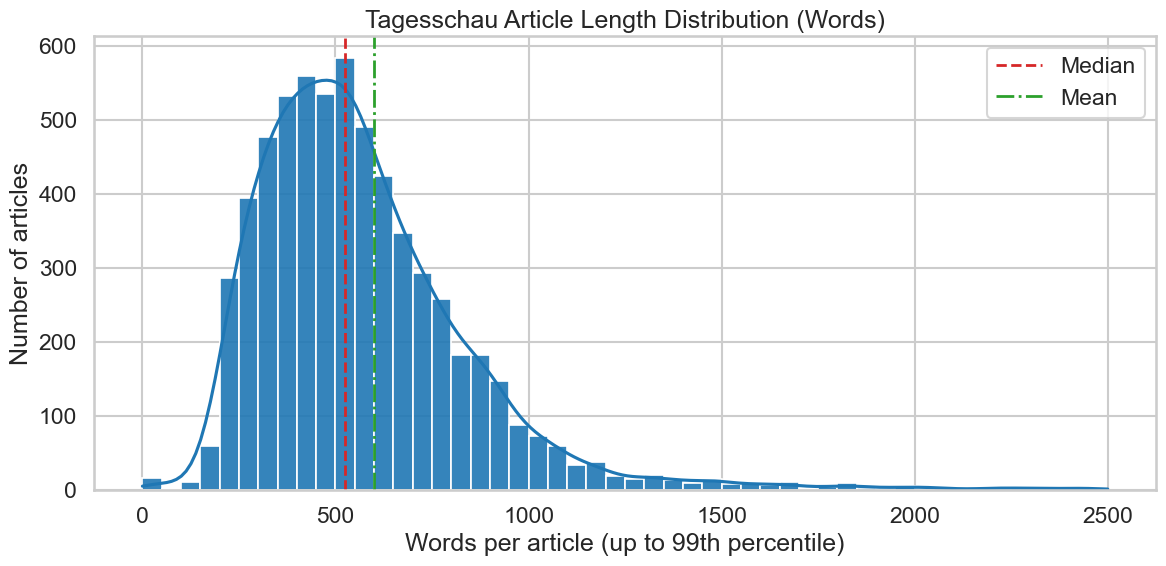

In [234]:
q99 = df_clean["article_length_words"].quantile(0.99)
length_plot = df_clean[df_clean["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(df_clean["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(df_clean["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("Tagesschau Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()


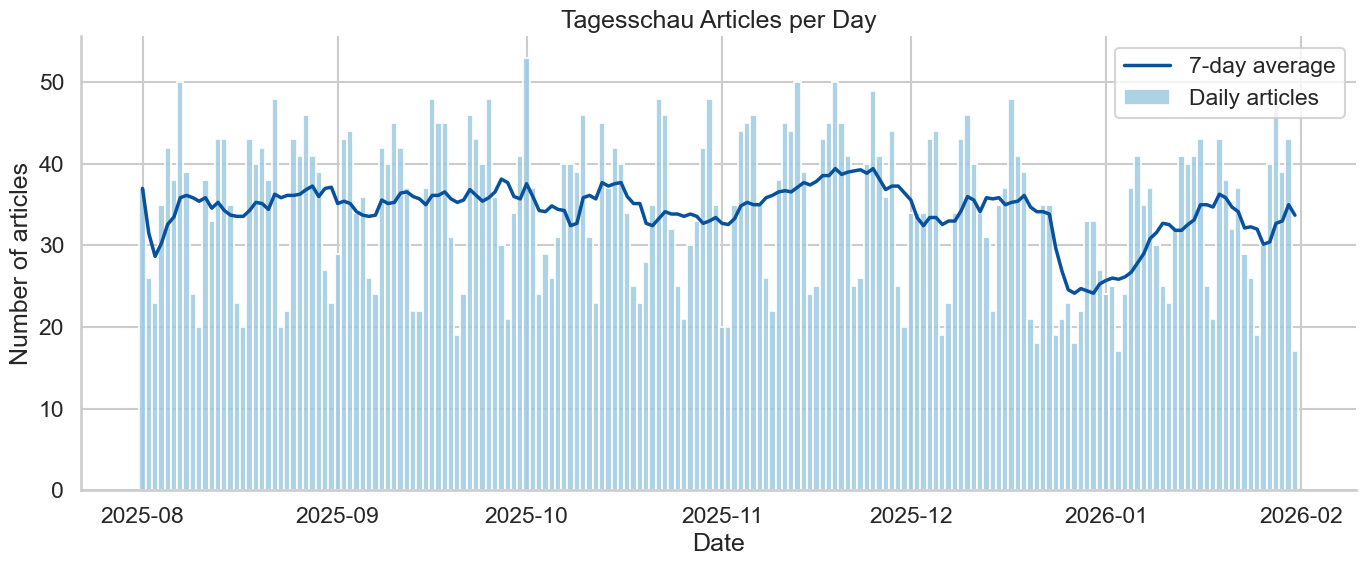

In [235]:
# Ensure datetime
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")

# Daily article counts (include missing days as 0)
daily_counts = (
    df_clean.dropna(subset=["Date"])
    .assign(Date=lambda d: d["Date"].dt.floor("D"))
    .groupby("Date")
    .size()
    .rename("articles")
    .sort_index()
    .asfreq("D", fill_value=0)
    .reset_index()
)

# 7-day rolling average
daily_counts["rolling_7d"] = daily_counts["articles"].rolling(7, min_periods=1).mean()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    daily_counts["Date"],
    daily_counts["articles"],
    color="#9ecae1",
    alpha=0.85,
    width=1.0,
    label="Daily articles",
)
ax.plot(
    daily_counts["Date"],
    daily_counts["rolling_7d"],
    color="#08519c",
    linewidth=2.5,
    label="7-day average",
)

ax.set_title("Tagesschau Articles per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Number of articles")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

In [236]:
tagesschau_clean = df_clean.copy()
tagesschau_clean["source"] = "Tagesschau"
tagesschau_clean = tagesschau_clean[["Date", "Title", "Text", "source"]].copy()
tagesschau_clean.to_csv("tagesschau_clean.csv", index=False, encoding="utf-8")

## BERTopic

In [22]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "data preprocessing":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [23]:
from BERTopic.bertopic_config import BERTopicConfig
from BERTopic.bertopic_pipeline import run_bertopic_pipeline

In [29]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(),
    id_col="URL",
    source_name="Tagesschau",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-11 18:49:32,837 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/196 [00:00<?, ?it/s]

2026-03-11 18:50:00,683 - BERTopic - Embedding - Completed ✓
2026-03-11 18:50:00,684 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-11 18:50:07,572 - BERTopic - Dimensionality - Completed ✓
2026-03-11 18:50:07,573 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-11 18:50:08,184 - BERTopic - Cluster - Completed ✓
2026-03-11 18:50:08,187 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-11 18:50:11,091 - BERTopic - Representation - Completed ✓


In [30]:
topic_info = result["topic_info"]
topic_info.head(30)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1876,-1_trump_eu_unternehmen_spd,"[trump, eu, unternehmen, spd, milliarden, merz...",[Auf dem Weltwirtschaftsforum in Davos hat Tru...
1,0,437,0_israel_hamas_gazastreifen_gaza,"[israel, hamas, gazastreifen, gaza, geiseln, i...",[Beim israelischen Militär laufen laut Spreche...
2,1,262,1_ukraine_putin_selenskyj_russland,"[ukraine, putin, selenskyj, russland, trump, t...",[Die US-Regierung erwägt einem Medienbericht z...
3,2,171,2_dax_dollar_punkten_anleger,"[dax, dollar, punkten, anleger, aktien, ki, ak...",[Nach schwachem Start haben sich die US-Börsen...
4,3,163,3_patienten_kinder_medikamente_studie,"[patienten, kinder, medikamente, studie, studi...",[Demenz ist nicht allein eine Frage des Alters...
5,4,151,4_bundesanwaltschaft_gericht_haft_prozess,"[bundesanwaltschaft, gericht, haft, prozess, s...","[Fünf Jahre Haft wegen ""außerordentlicher Schw..."
6,5,147,5_ukraine_russland_russischen_ukrainische,"[ukraine, russland, russischen, ukrainische, r...",[Laut dem ukrainischen Präsidenten Selenskyj e...
7,6,144,6_venezuela_maduro_trump_venezuelas,"[venezuela, maduro, trump, venezuelas, machado...",[Die USA haben Venezuela angegriffen und nach ...
8,7,113,7_ki_google_online_eu,"[ki, google, online, eu, kommission, unternehm...",[Die EU-Kommission will die Digital-Regeln zu ...
9,8,91,8_iran_proteste_teheran_iranische,"[iran, proteste, teheran, iranische, regime, i...",[US-Präsident Trump hat den Iran mehrfach vor ...


In [31]:
# pip install gensim
import re
import numpy as np
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel


def get_topic_words(topic_model, top_k=10, include_outlier=False):
    topic_info = topic_model.get_topic_info()
    topic_ids = topic_info["Topic"].tolist()
    if not include_outlier:
        topic_ids = [t for t in topic_ids if t != -1]

    topics = []
    for topic_id in topic_ids:
        terms = topic_model.get_topic(int(topic_id)) or []
        words = [w for w, _ in terms[:top_k]]
        if words:
            topics.append(words)
    return topics


def evaluate_bertopic(docs, topic_model, top_k=10):
    # 1) Topic words
    topics = get_topic_words(topic_model, top_k=top_k, include_outlier=False)
    if not topics:
        return {"coherence_npmi": np.nan, "topic_diversity": np.nan}

    # 2) Tokenize docs for coherence
    texts = [re.findall(r"(?u)\b\w\w+\b", str(doc).lower()) for doc in docs]
    dictionary = Dictionary(texts)

    # Keep only topic words that exist in corpus dictionary
    topics_for_coherence = [[w for w in t if w in dictionary.token2id] for t in topics]
    topics_for_coherence = [t for t in topics_for_coherence if len(t) >= 2]

    if not topics_for_coherence:
        coherence_npmi = np.nan
    else:
        cm = CoherenceModel(
            topics=topics_for_coherence,
            texts=texts,
            dictionary=dictionary,
            coherence="c_npmi",
        )
        coherence_npmi = cm.get_coherence()

    # 3) Topic diversity = unique words / (num_topics * top_k)
    all_words = [w for t in topics for w in t]
    topic_diversity = len(set(all_words)) / (len(topics) * top_k)

    return {
        "coherence_npmi": coherence_npmi,
        "topic_diversity": topic_diversity,
        "num_topics": len(topics),
        "top_k": top_k,
    }


# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics

{'coherence_npmi': 0.12053948440900654,
 'topic_diversity': 0.8450704225352113,
 'num_topics': 71,
 'top_k': 10}

In [32]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(
    hdbscan_min_cluster_size=25,
    hdbscan_min_samples=4,
    umap_n_neighbors=45,
    umap_min_dist=0.05,
),
    id_col="URL",
    source_name="Tagesschau",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-11 18:50:44,835 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/196 [00:00<?, ?it/s]

2026-03-11 18:51:12,605 - BERTopic - Embedding - Completed ✓
2026-03-11 18:51:12,606 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-11 18:51:20,961 - BERTopic - Dimensionality - Completed ✓
2026-03-11 18:51:20,961 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-11 18:51:21,355 - BERTopic - Cluster - Completed ✓
2026-03-11 18:51:21,357 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-11 18:51:24,513 - BERTopic - Representation - Completed ✓


In [33]:
topic_info = result["topic_info"]
topic_info.head(30)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1608,-1_eu_trump_unternehmen_milliarden,"[eu, trump, unternehmen, milliarden, ukraine, ...",[Geringere Zölle auf Stahl für gelockerte EU-D...
1,0,578,0_spd_afd_merz_cdu,"[spd, afd, merz, cdu, union, koalition, partei...",[Die CDU siegt bei den NRW-Kommunalwahlen klar...
2,1,439,1_israel_hamas_gazastreifen_gaza,"[israel, hamas, gazastreifen, gaza, geiseln, i...","[Das israelische Militär geht davon aus, dass ..."
3,2,250,2_patienten_kinder_studie_warken,"[patienten, kinder, studie, warken, medikament...",[Demenz ist nicht allein eine Frage des Alters...
4,3,232,3_ukraine_putin_selenskyj_trump,"[ukraine, putin, selenskyj, trump, russland, r...",[Laut US-Außenminister Rubio ist nach dem Tref...
5,4,200,4_venezuela_maduro_trump_venezuelas,"[venezuela, maduro, trump, venezuelas, machado...",[Im Kampf gegen den Drogenhandel nehmen die US...
6,5,192,5_dax_dollar_anleger_punkten,"[dax, dollar, anleger, punkten, fed, ki, aktie...",[Nach schwachem Start haben sich die US-Börsen...
7,6,177,6_ukraine_russland_russischen_russische,"[ukraine, russland, russischen, russische, ukr...",[Laut dem ukrainischen Präsidenten Selenskyj e...
8,7,140,7_bundesanwaltschaft_gericht_haft_prozess,"[bundesanwaltschaft, gericht, haft, prozess, s...","[Fünf Jahre Haft wegen ""außerordentlicher Schw..."
9,8,134,8_china_xi_trump_peking,"[china, xi, trump, peking, chinas, chinesische...","[Tausende Soldaten, moderne Waffen und eine Ze..."


In [34]:
# 1) BERTopic on full article text
result_full_text_ts = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(
    hdbscan_min_cluster_size=35,
    hdbscan_min_samples=2,
    umap_n_neighbors=25,
    umap_min_dist=0.0,
),
    id_col="URL",
    source_name="Tagesschau",
)

# Keep downstream notebook cells unchanged (they use `result`)
result_ts = result_full_text_ts

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-11 18:51:31,833 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/196 [00:00<?, ?it/s]

2026-03-11 18:52:02,979 - BERTopic - Embedding - Completed ✓
2026-03-11 18:52:02,979 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-11 18:52:09,348 - BERTopic - Dimensionality - Completed ✓
2026-03-11 18:52:09,348 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-11 18:52:09,711 - BERTopic - Cluster - Completed ✓
2026-03-11 18:52:09,717 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-11 18:52:12,745 - BERTopic - Representation - Completed ✓


In [35]:
topic_info_ts = result_ts["topic_info"]
topic_info_ts.head(45)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1474,-1_afd_trump_epstein_partei,"[afd, trump, epstein, partei, spd, cdu, merz, ...",[US-Präsident Trump hat das Gesetz zur Veröffe...
1,0,439,0_israel_hamas_gazastreifen_gaza,"[israel, hamas, gazastreifen, gaza, geiseln, i...",[Die Hamas erklärt nach Zusicherungen der US-R...
2,1,277,1_ukraine_putin_selenskyj_trump,"[ukraine, putin, selenskyj, trump, russland, r...",[US-Präsident Trump hat Medienberichten zufolg...
3,2,205,2_venezuela_maduro_trump_venezuelas,"[venezuela, maduro, trump, venezuelas, machado...",[Die USA haben Venezuela angegriffen und nach ...
4,3,192,3_dax_dollar_anleger_punkten,"[dax, dollar, anleger, punkten, aktien, ki, ak...",[Die starken Quartalsberichte der Techgiganten...
5,4,173,4_social media_media_jugendliche_social,"[social media, media, jugendliche, social, jug...",[Ein Mindestalter für Soziale Netzwerke - dies...
6,5,162,5_ukraine_russland_russischen_ukrainische,"[ukraine, russland, russischen, ukrainische, r...",[Russischen Soldaten ist es nach Angaben aus K...
7,6,161,6_patienten_medikamente_studien_studie,"[patienten, medikamente, studien, studie, erkr...",[Die geplante Apothekenreform nimmt Gestalt an...
8,7,160,7_preise_lebensmittel_verbraucher_weihnachten,"[preise, lebensmittel, verbraucher, weihnachte...",[Wird Kaffee zum Luxusprodukt? Im August haben...
9,8,154,8_bundesanwaltschaft_gericht_haft_prozess,"[bundesanwaltschaft, gericht, haft, prozess, s...",[Die Bundesanwaltschaft hält einen 49 Jahre al...


In [36]:
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics

{'coherence_npmi': 0.09795818627010149,
 'topic_diversity': 0.8622641509433963,
 'num_topics': 53,
 'top_k': 10}

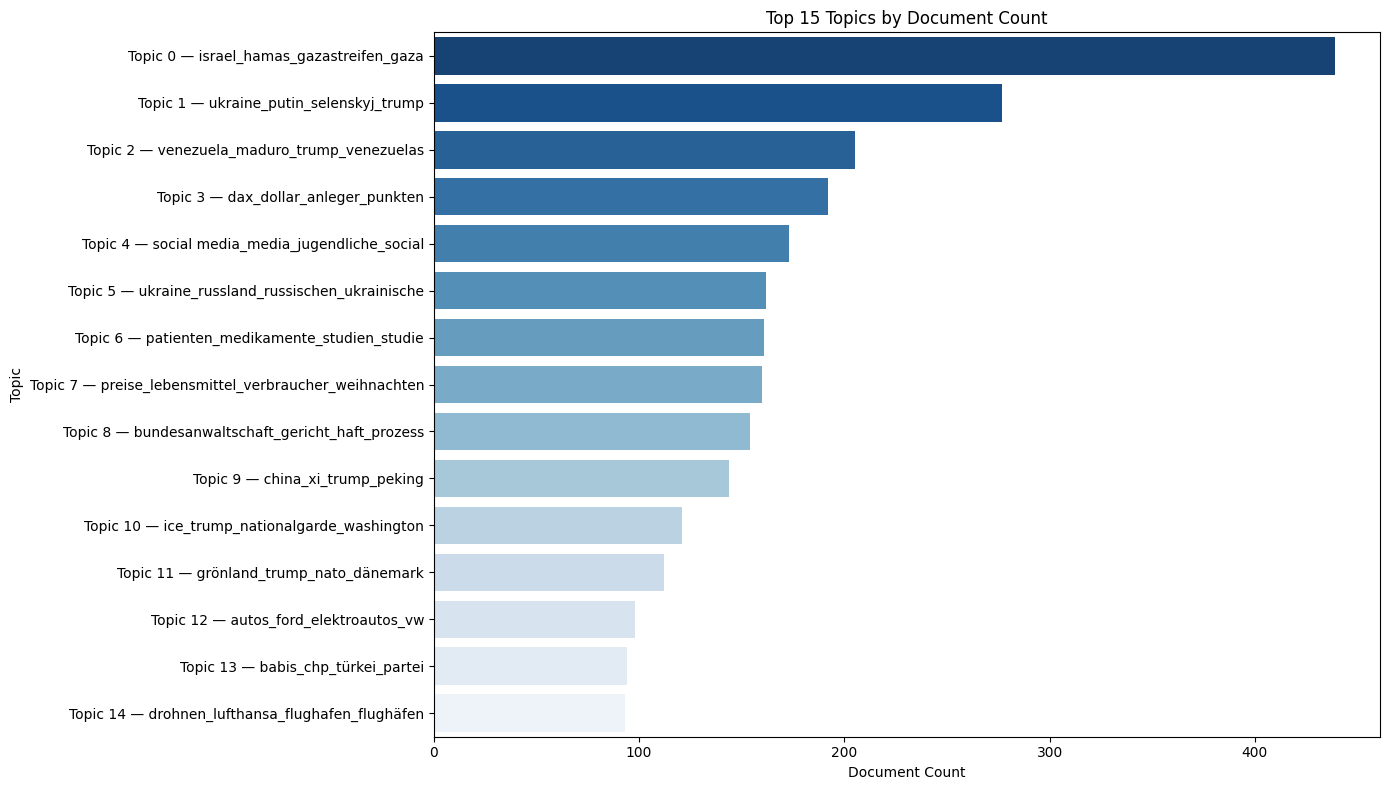

In [37]:
import seaborn as sns

# Ensure plotting libs exist in current kernel
import matplotlib.pyplot as plt

# Bar chart: first 15 non-outlier topics from the run model (with topic names)
run_result = result_ts
topic_info_run = run_result["topic_info"].copy()

top15_topics = topic_info_run.loc[topic_info_run["Topic"] != -1].head(15).copy()

# Clean topic name (remove leading "<topic_id>_")
top15_topics["TopicName"] = top15_topics["Name"].str.replace(r"^\d+_", "", regex=True)

# Combine topic id + readable name for y-axis
top15_topics["TopicLabel"] = (
    "Topic " + top15_topics["Topic"].astype(str) + " — " + top15_topics["TopicName"]
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(data=top15_topics, x="Count", y="TopicLabel", palette="Blues_r", ax=ax)

ax.set_title("Top 15 Topics by Document Count")
ax.set_xlabel("Document Count")
ax.set_ylabel("Topic")
plt.tight_layout()
plt.show()

In [ ]:
#Intertopic distance map
result_ts["topic_model"].visualize_topics()

In [ ]:
# # In 06_Tagesschau.ipynb
# ts_model = result_ts["topic_model"]
# PROJECT_ROOT = Path.cwd().resolve().parent  # if notebook is in "data preprocessing"
# ts_model.save(
#     PROJECT_ROOT / "BERTopic" / "outputs" / "ts_model",
#     serialization="safetensors",
#     save_ctfidf=True,
#     save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
# )


In [ ]:
# # In 06_Tagesschau.ipynb (after result_full_text is created)
# import joblib
# from pathlib import Path

# PROJECT_ROOT = Path.cwd().resolve().parent  # if notebook is in "data preprocessing"
# result_ts = result_full_text
# joblib.dump(result_ts, PROJECT_ROOT / "BERTopic" / "outputs" / "result_ts.joblib")


6it [00:17,  2.91s/it]


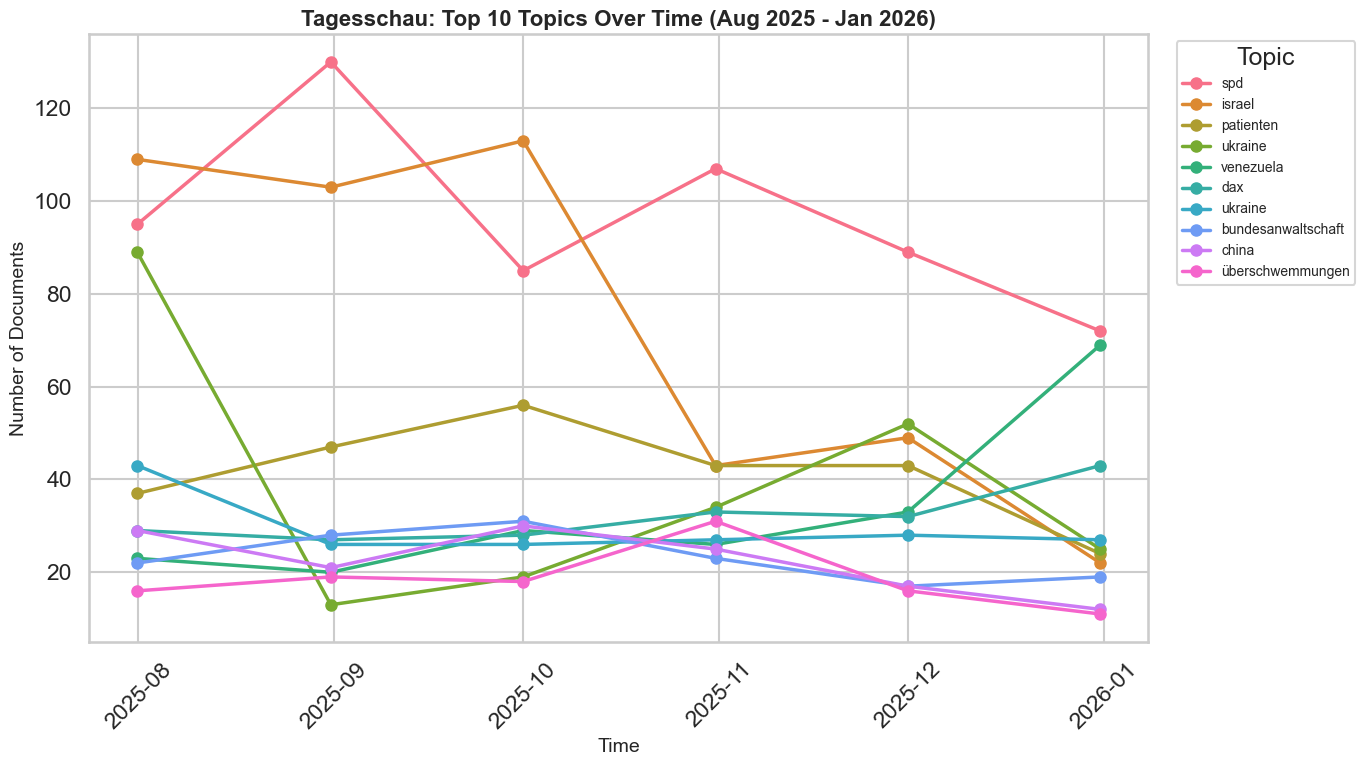

In [ ]:
# Prepare data for topics over time
topics_over_time = result["topic_model"].topics_over_time(
    result["docs"],
    result["prepared_documents"]["Date"].tolist(),
    nr_bins=6
)

# Get top 10 topics by count (excluding -1)
top_10_topics = topic_info[topic_info['Topic'] != -1].nlargest(10, 'Count')['Topic'].tolist()

# Filter for top 10 topics
topics_over_time_filtered = topics_over_time[topics_over_time['Topic'].isin(top_10_topics)]

# Create topic name mapping
topic_name_map = dict(zip(topic_info['Topic'], topic_info['Name']))

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered['Topic'] == topic]
    label = topic_name_map.get(topic, f"Topic {topic}")
    # Shorten label for legend
    short_label = label.split('_')[1] if '_' in label else label
    ax.plot(topic_data['Timestamp'], topic_data['Frequency'], 
            marker='o', linewidth=2.5, markersize=8, 
            color=palette[i], label=short_label)

ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Number of Documents', fontsize=14)
ax.set_title('Tagesschau: Top 10 Topics Over Time (Aug 2025 - Jan 2026)', fontsize=16, fontweight='bold')
ax.legend(title='Topic', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Outlier Reduction (same fitted BERTopic model)
Nochmal mit calc. Probs runnen



In [40]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "data preprocessing":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from BERTopic.bertopic_config import BERTopicConfig
from BERTopic.bertopic_pipeline import run_bertopic_pipeline

# Fresh baseline model for experiments
result_ts_base = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(
        hdbscan_min_cluster_size=35,
        hdbscan_min_samples=2,
        umap_n_neighbors=25,
        umap_min_dist=0.0,
        # IMPORTANT: only if your config/wrapper supports it
        calculate_probabilities=True,
    ),
    id_col="URL",
    source_name="Tagesschau",
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-11 18:53:08,476 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/196 [00:00<?, ?it/s]

2026-03-11 18:53:43,731 - BERTopic - Embedding - Completed ✓
2026-03-11 18:53:43,732 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-11 18:53:51,745 - BERTopic - Dimensionality - Completed ✓
2026-03-11 18:53:51,748 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-11 18:53:52,120 - BERTopic - Cluster - Completed ✓
2026-03-11 18:53:52,127 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-11 18:53:55,313 - BERTopic - Representation - Completed ✓


In [42]:
from copy import deepcopy
import pandas as pd

topic_model_base = result_ts_base["topic_model"]
docs_ts = result_ts_base["docs"]
topics_ts = list(result_ts_base["topics"])

# only available if pipeline stores them
probs_ts = result_ts_base.get("probs", None)
embeddings_ts = result_ts_base.get("embeddings", None)

# save original representation components
orig_vectorizer = deepcopy(topic_model_base.vectorizer_model)
orig_ctfidf = deepcopy(topic_model_base.ctfidf_model)
orig_representation = deepcopy(topic_model_base.representation_model)
orig_top_n_words = topic_model_base.top_n_words

before_outliers = sum(1 for t in topics_ts if t == -1)
print(f"Baseline docs: {len(docs_ts):,}")
print(f"Baseline outliers (-1): {before_outliers:,}")
print(f"Probabilities available: {probs_ts is not None}")
print(f"Embeddings available: {embeddings_ts is not None}")

Baseline docs: 6,272
Baseline outliers (-1): 1,474
Probabilities available: False
Embeddings available: False


In [43]:
print(result_ts_base.keys())
print(type(result_ts_base.get("probabilities")))
print(result_ts_base.get("probabilities") is None)
print(result_ts_base["config"].calculate_probabilities)

dict_keys(['config', 'prepared_documents', 'docs', 'topic_model', 'topics', 'probabilities', 'topic_info', 'doc_info'])
<class 'numpy.ndarray'>
False
True


In [ ]:
topic_model_base = result_ts_base["topic_model"]
docs_ts = result_ts_base["docs"]
topics_ts = list(result_ts_base["topics"])
probs_ts = result_ts_base["probabilities"]

experiments = {}

experiments["probabilities_085"] = topic_model_base.reduce_outliers(
    docs_ts,
    topics_ts,
    probabilities=probs_ts,
    strategy="probabilities",
    threshold=0.85,
)

experiments["probabilities_090"] = topic_model_base.reduce_outliers(
    docs_ts,
    topics_ts,
    probabilities=probs_ts,
    strategy="probabilities",
    threshold=0.90,
)

experiments["ctfidf_010"] = topic_model_base.reduce_outliers(
    docs_ts,
    topics_ts,
    strategy="c-tf-idf",
    threshold=0.10,
)

experiments["ctfidf_015"] = topic_model_base.reduce_outliers(
    docs_ts,
    topics_ts,
    strategy="c-tf-idf",
    threshold=0.15,
)

experiments["distributions"] = topic_model_base.reduce_outliers(
    docs_ts,
    topics_ts,
    strategy="distributions",
)

100%|██████████| 2/2 [00:08<00:00,  4.32s/it]


## Outlier reduction experiments

A fresh baseline BERTopic model (`result_ts_base`) was kept unchanged.

We then generated alternative topic assignments for outlier documents using several BERTopic outlier-reduction strategies:

- `probabilities` with thresholds `0.85` and `0.90`
- `c-tf-idf` with thresholds `0.10` and `0.15`
- `distributions`

At this stage, only new topic assignment vectors were created and stored in `experiments`.  
The BERTopic model itself has **not** been updated yet, meaning that no topic representations were overwritten.

### What follows next
The next step is to compare all strategies quantitatively and then inspect the most promising candidates qualitatively.

This will be done by:
1. comparing the number of remaining outliers and changed assignments,
2. materializing selected candidates on copies of the baseline model via `update_topics(...)`,
3. checking topic interpretability through topic labels, representations, and representative documents,
4. selecting the best trade-off between fewer outliers and coherent topics.

Only after this comparison will the final outlier-reduced model be chosen.

In [ ]:
import pandas as pd

before_outliers = sum(1 for t in topics_ts if t == -1)

summary_rows = []

for name, new_topics in experiments.items():
    after_outliers = sum(1 for t in new_topics if t == -1)

    reassigned_from_outlier = sum(
        1 for old_t, new_t in zip(topics_ts, new_topics)
        if old_t == -1 and new_t != -1
    )

    changed_total = sum(
        1 for old_t, new_t in zip(topics_ts, new_topics)
        if old_t != new_t
    )

    summary_rows.append({
        "experiment": name,
        "outliers_before": before_outliers,
        "outliers_after": after_outliers,
        "reassigned_from_-1": reassigned_from_outlier,
        "changed_total": changed_total,
    })

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values(["outliers_after", "changed_total"])
    .reset_index(drop=True)
)

summary_df

,experiment,outliers_before,outliers_after,reassigned_from_-1,changed_total
0,distributions,1474,0,1474,1474
1,ctfidf_010,1474,791,683,683
2,ctfidf_015,1474,1214,260,260
3,probabilities_085,1474,1474,0,0
4,probabilities_090,1474,1474,0,0


In [ ]:
from copy import deepcopy

def build_updated_result(base_result, new_topics):
    topic_model_tmp = deepcopy(base_result["topic_model"])

    vectorizer_tmp = deepcopy(topic_model_tmp.vectorizer_model)
    ctfidf_tmp = deepcopy(topic_model_tmp.ctfidf_model)
    representation_tmp = deepcopy(topic_model_tmp.representation_model)
    top_n_words_tmp = topic_model_tmp.top_n_words

    topic_model_tmp.update_topics(
        base_result["docs"],
        topics=new_topics,
        vectorizer_model=vectorizer_tmp,
        ctfidf_model=ctfidf_tmp,
        representation_model=representation_tmp,
        top_n_words=top_n_words_tmp,
    )

    updated_result = dict(base_result)
    updated_result["topics"] = new_topics
    updated_result["topic_model"] = topic_model_tmp
    updated_result["topic_info"] = topic_model_tmp.get_topic_info()
    updated_result["doc_info"] = topic_model_tmp.get_document_info(base_result["docs"])

    return updated_result

In [ ]:
candidate_names = ["ctfidf_010", "ctfidf_015", "distributions"]

candidate_results = {}

for name in candidate_names:
    candidate_results[name] = build_updated_result(result_ts_base, experiments[name])
    print(f"\n===== {name} =====")
    display(candidate_results[name]["topic_info"].head(25))

2026-03-10 16:41:03,193 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.



===== ctfidf_010 =====


,Topic,Count,Name,Representation,Representative_Docs
0,-1,791,-1_papst_afd_kirche_leo,"[papst, afd, kirche, leo, kirk, erde, mond, ab...",[US-Präsident Trump hat das Gesetz zur Veröffe...
1,0,446,0_israel_hamas_gazastreifen_gaza,"[israel, hamas, gazastreifen, gaza, geiseln, i...",[Die Hamas erklärt nach Zusicherungen der US-R...
2,1,303,1_ukraine_putin_selenskyj_trump,"[ukraine, putin, selenskyj, trump, russland, r...",[US-Präsident Trump hat Medienberichten zufolg...
3,2,206,2_venezuela_maduro_trump_venezuelas,"[venezuela, maduro, trump, venezuelas, machado...",[Die USA haben Venezuela angegriffen und nach ...
4,3,239,3_dollar_dax_anleger_punkten,"[dollar, dax, anleger, punkten, fed, aktien, a...",[Die starken Quartalsberichte der Techgiganten...
5,4,186,4_social media_media_jugendliche_social,"[social media, media, jugendliche, social, gew...",[Ein Mindestalter für Soziale Netzwerke - dies...
6,5,190,5_ukraine_russland_russischen_ukrainische,"[ukraine, russland, russischen, ukrainische, r...",[Russischen Soldaten ist es nach Angaben aus K...
7,6,175,6_patienten_medikamente_studie_erkrankungen,"[patienten, medikamente, studie, erkrankungen,...",[Die geplante Apothekenreform nimmt Gestalt an...
8,7,166,7_preise_lebensmittel_verbraucher_weihnachten,"[preise, lebensmittel, verbraucher, weihnachte...",[Wird Kaffee zum Luxusprodukt? Im August haben...
9,8,168,8_bundesanwaltschaft_gericht_haft_prozess,"[bundesanwaltschaft, gericht, haft, prozess, s...",[Die Bundesanwaltschaft hält einen 49 Jahre al...


2026-03-10 16:41:08,105 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.



===== ctfidf_015 =====


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1214,-1_afd_trump_epstein_partei,"[afd, trump, epstein, partei, kirk, demokraten...",[US-Präsident Trump hat das Gesetz zur Veröffe...
1,0,440,0_israel_hamas_gazastreifen_gaza,"[israel, hamas, gazastreifen, gaza, geiseln, i...",[Die Hamas erklärt nach Zusicherungen der US-R...
2,1,293,1_ukraine_putin_selenskyj_trump,"[ukraine, putin, selenskyj, trump, russland, r...",[US-Präsident Trump hat Medienberichten zufolg...
3,2,206,2_venezuela_maduro_trump_venezuelas,"[venezuela, maduro, trump, venezuelas, machado...",[Die USA haben Venezuela angegriffen und nach ...
4,3,212,3_dax_dollar_anleger_punkten,"[dax, dollar, anleger, punkten, fed, aktien, k...",[Die starken Quartalsberichte der Techgiganten...
5,4,177,4_social media_media_jugendliche_social,"[social media, media, jugendliche, social, gew...",[Ein Mindestalter für Soziale Netzwerke - dies...
6,5,173,5_ukraine_russland_russischen_ukrainische,"[ukraine, russland, russischen, ukrainische, r...",[Russischen Soldaten ist es nach Angaben aus K...
7,6,162,6_patienten_medikamente_studien_studie,"[patienten, medikamente, studien, studie, erkr...",[Die geplante Apothekenreform nimmt Gestalt an...
8,7,160,7_preise_lebensmittel_verbraucher_weihnachten,"[preise, lebensmittel, verbraucher, weihnachte...",[Wird Kaffee zum Luxusprodukt? Im August haben...
9,8,155,8_bundesanwaltschaft_gericht_haft_prozess,"[bundesanwaltschaft, gericht, haft, prozess, s...",[Die Bundesanwaltschaft hält einen 49 Jahre al...


2026-03-10 16:41:13,129 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.



===== distributions =====


,Topic,Count,Name,Representation,Representative_Docs
0,0,456,0_israel_hamas_gazastreifen_gaza,"[israel, hamas, gazastreifen, gaza, geiseln, i...",[Die Hamas erklärt nach Zusicherungen der US-R...
1,1,313,1_putin_selenskyj_russland_trump,"[putin, selenskyj, russland, trump, russischen...",[US-Präsident Trump hat Medienberichten zufolg...
2,2,208,2_venezuela_maduro_trump_venezuelas,"[venezuela, maduro, trump, venezuelas, machado...",[Die USA haben Venezuela angegriffen und nach ...
3,3,263,3_dollar_dax_anleger_punkten,"[dollar, dax, anleger, punkten, fed, aktien, a...",[Die starken Quartalsberichte der Techgiganten...
4,4,259,4_media_social media_gewalt_jugendliche,"[media, social media, gewalt, jugendliche, soc...",[Ein Mindestalter für Soziale Netzwerke - dies...
5,5,200,5_russland_russischen_russische_ukrainische,"[russland, russischen, russische, ukrainische,...",[Russischen Soldaten ist es nach Angaben aus K...
6,6,216,6_patienten_medikamente_studie_studien,"[patienten, medikamente, studie, studien, erkr...",[Die geplante Apothekenreform nimmt Gestalt an...
7,7,206,7_preise_lebensmittel_verbraucher_weihnachten,"[preise, lebensmittel, verbraucher, weihnachte...",[Wird Kaffee zum Luxusprodukt? Im August haben...
8,8,203,8_gericht_bundesanwaltschaft_staatsanwaltschaf...,"[gericht, bundesanwaltschaft, staatsanwaltscha...",[Die Bundesanwaltschaft hält einen 49 Jahre al...
9,9,170,9_indien_xi_trump_peking,"[indien, xi, trump, peking, chinas, chinesisch...",[China hat auf die Zoll-Drohungen von US-Präsi...


## New: Outlier Reduction (Embeddings Strategy)

Use BERTopic's `reduce_outliers(..., strategy="embeddings")` on the already fitted Tagesschau model (no new BERTopic fit).


In [ ]:
import pandas as pd

# Reuse the already fitted BERTopic result from this notebook.
base_result = result_ts_base if 'result_ts_base' in globals() else (result_ts if 'result_ts' in globals() else result)

topic_model_base = base_result['topic_model']
docs_ts = base_result['docs']
topics_ts = list(base_result['topics'])
embeddings_ts = base_result.get('embeddings', None)

# Reduce only outlier docs (-1) by matching document embeddings to topic embeddings.
topics_embeddings = topic_model_base.reduce_outliers(
    docs_ts,
    topics_ts,
    strategy='embeddings',
    embeddings=embeddings_ts,
)

outliers_before = int((pd.Series(topics_ts) == -1).sum())
outliers_after = int((pd.Series(topics_embeddings) == -1).sum())
print({'outliers_before': outliers_before, 'outliers_after': outliers_after})

# Optional: create an updated result for downstream tables/plots.
if 'build_updated_result' in globals():
    result_ts_embeddings = build_updated_result(base_result, topics_embeddings)
    display(result_ts_embeddings['topic_info'].head(25))


## Outlier Reduction Strategies

We now test BERTopic outlier-reduction methods exactly as documented, using the same fitted model and document set.
This lets us compare how each method reassigns topic `-1` documents and how topic counts/representations change.


In [45]:
import pandas as pd
from copy import deepcopy

# Reuse already fitted Tagesschau BERTopic result (no new fit).
base_result = result_ts_base if "result_ts_base" in globals() else (result_ts if "result_ts" in globals() else result)
topic_model = base_result["topic_model"]
docs = base_result["docs"]
topics = list(base_result["topics"])
probs = base_result.get("probabilities", None)

vec = topic_model.vectorizer_model
stop_words = getattr(vec, "stop_words", None)
core_sw = {"die", "der", "das", "und", "in"}
has_core_sw = isinstance(stop_words, (list, set, tuple, frozenset)) and core_sw.issubset(set(stop_words))

print("docs:", len(docs))
print("initial outliers (-1):", int((pd.Series(topics) == -1).sum()))
print("calculate_probabilities:", getattr(base_result.get("config", None), "calculate_probabilities", "unknown"))
print("probabilities available:", probs is not None)
print("vectorizer:", type(vec).__name__)
print("vectorizer has stop_words:", stop_words is not None)
print("vectorizer contains core DE stopwords (die/der/das/und/in):", has_core_sw)


docs: 6272
initial outliers (-1): 1474
calculate_probabilities: True
probabilities available: True
vectorizer: CountVectorizer
vectorizer has stop_words: True
vectorizer contains core DE stopwords (die/der/das/und/in): True


In [46]:
# Probabilities strategy (requires calculate_probabilities=True).
if probs is None:
    raise ValueError("`probs` is None. Re-run BERTopic with calculate_probabilities=True before this step.")

new_topics_prob = topic_model.reduce_outliers(docs, topics, probabilities=probs, strategy="probabilities")
print("outliers after probabilities:", int((pd.Series(new_topics_prob) == -1).sum()))


outliers after probabilities: 0


In [47]:
# Topic distributions strategy.
new_topics_dist = topic_model.reduce_outliers(docs, topics, strategy="distributions")
print("outliers after distributions:", int((pd.Series(new_topics_dist) == -1).sum()))


100%|██████████| 2/2 [00:03<00:00,  1.59s/it]

outliers after distributions: 0


In [48]:
# c-TF-IDF strategy.
new_topics_ctfidf = topic_model.reduce_outliers(docs, topics, strategy="c-tf-idf")
print("outliers after c-tf-idf:", int((pd.Series(new_topics_ctfidf) == -1).sum()))


outliers after c-tf-idf: 0


In [49]:
# Embeddings strategy.
new_topics_embed = topic_model.reduce_outliers(docs, topics, strategy="embeddings")
print("outliers after embeddings:", int((pd.Series(new_topics_embed) == -1).sum()))


outliers after embeddings: 0


In [50]:
# Chain strategy: first c-TF-IDF, then distributions.
new_topics_chain = topic_model.reduce_outliers(docs, topics, strategy="c-tf-idf", threshold=0.1)
new_topics_chain = topic_model.reduce_outliers(docs, new_topics_chain, strategy="distributions")
print("outliers after chain:", int((pd.Series(new_topics_chain) == -1).sum()))


100%|██████████| 1/1 [00:01<00:00,  1.51s/it]

outliers after chain: 0


In [51]:
# Update topic representations while preserving original BERTopic components
# (same model stack; only topic assignments change).
from sklearn.feature_extraction.text import CountVectorizer
from BERTopic.stopwords_de import get_german_stopwords

def _has_core_de_stopwords(vectorizer_model):
    sw = getattr(vectorizer_model, "stop_words", None)
    core = {"die", "der", "das", "und", "in"}
    return isinstance(sw, (list, set, tuple, frozenset)) and core.issubset(set(sw))

def _pipeline_equivalent_vectorizer(vectorizer_model):
    params = vectorizer_model.get_params(deep=False)
    if params.get("stop_words") is None:
        params["stop_words"] = get_german_stopwords()
    return CountVectorizer(**params)

def _update_with_same_components(model, docs, new_topics):
    model_tmp = deepcopy(model)
    vectorizer_tmp = deepcopy(model_tmp.vectorizer_model)

    # Guardrail: if current model lacks stopword config, enforce pipeline-equivalent vectorizer.
    if not _has_core_de_stopwords(vectorizer_tmp):
        vectorizer_tmp = _pipeline_equivalent_vectorizer(model_tmp.vectorizer_model)

    ctfidf_tmp = deepcopy(model_tmp.ctfidf_model)
    representation_tmp = deepcopy(model_tmp.representation_model)
    top_n_words_tmp = model_tmp.top_n_words

    model_tmp.update_topics(
        docs,
        topics=new_topics,
        vectorizer_model=vectorizer_tmp,
        ctfidf_model=ctfidf_tmp,
        representation_model=representation_tmp,
        top_n_words=top_n_words_tmp,
    )
    return model_tmp

topic_model_prob = _update_with_same_components(topic_model, docs, new_topics_prob)
topic_model_dist = _update_with_same_components(topic_model, docs, new_topics_dist)
topic_model_ctfidf = _update_with_same_components(topic_model, docs, new_topics_ctfidf)
topic_model_embed = _update_with_same_components(topic_model, docs, new_topics_embed)
topic_model_chain = _update_with_same_components(topic_model, docs, new_topics_chain)

print("Updated topic representations for all strategies with stopword guardrail.")


2026-03-11 18:57:26,472 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.
2026-03-11 18:57:30,406 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.
2026-03-11 18:57:34,391 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF em

Updated topic representations for all strategies with stopword guardrail.


In [52]:
def _topic_info_compact(model, strategy_name):
    ti = model.get_topic_info().copy()
    if "Representation" in ti.columns:
        ti["Representation_str"] = ti["Representation"].apply(
            lambda x: ", ".join(x) if isinstance(x, (list, tuple)) else str(x)
        )
    else:
        ti["Representation_str"] = ""
    ti = ti[["Topic", "Count", "Name", "Representation_str"]].copy()
    ti["Strategy"] = strategy_name
    return ti

# Baseline + updated strategy models
topic_info_baseline = _topic_info_compact(topic_model, "baseline")
topic_info_prob = _topic_info_compact(topic_model_prob, "probabilities")
topic_info_dist = _topic_info_compact(topic_model_dist, "distributions")
topic_info_ctfidf = _topic_info_compact(topic_model_ctfidf, "c-tf-idf")
topic_info_embed = _topic_info_compact(topic_model_embed, "embeddings")
topic_info_chain = _topic_info_compact(topic_model_chain, "chain_ctfidf_then_distributions")

topic_info_all = pd.concat([
    topic_info_baseline,
    topic_info_prob,
    topic_info_dist,
    topic_info_ctfidf,
    topic_info_embed,
    topic_info_chain,
], ignore_index=True)

# 1) Side-by-side count comparison by topic
count_comparison = topic_info_all.pivot_table(
    index="Topic",
    columns="Strategy",
    values="Count",
    aggfunc="first"
).sort_index()

# 2) Explicit outlier (-1) comparison
outlier_comparison = topic_info_all[topic_info_all["Topic"] == -1][
    ["Strategy", "Topic", "Count", "Name", "Representation_str"]
].sort_values("Count")

# 3) Name + representation side-by-side for a compact set of key topics
baseline_top_topics = topic_info_baseline[topic_info_baseline["Topic"] != -1].nlargest(10, "Count")["Topic"].tolist()
key_topics = sorted(set([-1] + baseline_top_topics))
details = topic_info_all[topic_info_all["Topic"].isin(key_topics)].copy()

name_comparison = details.pivot_table(
    index="Topic",
    columns="Strategy",
    values="Name",
    aggfunc="first"
).sort_index()

representation_comparison = details.pivot_table(
    index="Topic",
    columns="Strategy",
    values="Representation_str",
    aggfunc="first"
).sort_index()

print("Outlier (-1) comparison:")
display(outlier_comparison)

print("Topic count comparison (all topics):")
display(count_comparison)

print("Topic name comparison (baseline top topics + -1):")
display(name_comparison)

print("Topic representation comparison (baseline top topics + -1):")
display(representation_comparison)


Outlier (-1) comparison:


,Strategy,Topic,Count,Name,Representation_str
0,baseline,-1,1474,-1_afd_trump_epstein_partei,"afd, trump, epstein, partei, spd, cdu, merz, d..."


Topic count comparison (all topics):


Strategy,baseline,c-tf-idf,chain_ctfidf_then_distributions,distributions,embeddings,probabilities
Topic,,,,,,
-1,1474.0,NaN,NaN,NaN,NaN,NaN
0,439.0,457.0,457.0,456.0,444.0,439.0
1,277.0,306.0,309.0,313.0,298.0,318.0
2,205.0,208.0,208.0,208.0,210.0,205.0
3,192.0,266.0,263.0,263.0,213.0,210.0
4,173.0,262.0,259.0,259.0,223.0,228.0
5,162.0,202.0,205.0,200.0,187.0,170.0
6,161.0,219.0,216.0,216.0,193.0,229.0
7,160.0,210.0,206.0,206.0,180.0,189.0


Topic name comparison (baseline top topics + -1):


Strategy,baseline,c-tf-idf,chain_ctfidf_then_distributions,distributions,embeddings,probabilities
Topic,,,,,,
-1,-1_afd_trump_epstein_partei,NaN,NaN,NaN,NaN,NaN
0,0_israel_hamas_gazastreifen_gaza,0_israel_hamas_gazastreifen_gaza,0_israel_hamas_gazastreifen_gaza,0_israel_hamas_gazastreifen_gaza,0_israel_hamas_gazastreifen_gaza,0_israel_hamas_gazastreifen_gaza
1,1_ukraine_putin_selenskyj_trump,1_putin_selenskyj_trump_russland,1_putin_selenskyj_trump_russland,1_putin_selenskyj_russland_trump,1_putin_selenskyj_russland_trump,1_ukraine_selenskyj_putin_russland
2,2_venezuela_maduro_trump_venezuelas,2_venezuela_maduro_trump_venezuelas,2_venezuela_maduro_trump_venezuelas,2_venezuela_maduro_trump_venezuelas,2_venezuela_maduro_trump_venezuelas,2_venezuela_maduro_trump_venezuelas
3,3_dax_dollar_anleger_punkten,3_dollar_dax_anleger_punkten,3_dollar_dax_anleger_punkten,3_dollar_dax_anleger_punkten,3_dax_dollar_anleger_punkten,3_dax_dollar_anleger_punkten
4,4_social media_media_jugendliche_social,4_media_social media_gewalt_jugendliche,4_media_social media_gewalt_jugendliche,4_media_social media_gewalt_jugendliche,4_social media_media_jugendliche_social,4_social media_jugendliche_media_gewalt
5,5_ukraine_russland_russischen_ukrainische,5_russland_russischen_russische_ukrainische,5_russland_russischen_russische_ukrainische,5_russland_russischen_russische_ukrainische,5_russland_russischen_russische_ukrainische,5_ukraine_russland_russischen_russische
6,6_patienten_medikamente_studien_studie,6_patienten_medikamente_studie_studien,6_patienten_medikamente_studie_studien,6_patienten_medikamente_studie_studien,6_patienten_medikamente_studie_studien,6_patienten_medikamente_warken_studie
7,7_preise_lebensmittel_verbraucher_weihnachten,7_preise_lebensmittel_verbraucher_weihnachten,7_preise_lebensmittel_verbraucher_weihnachten,7_preise_lebensmittel_verbraucher_weihnachten,7_preise_lebensmittel_verbraucher_weihnachten,7_papst_leo_preise_lebensmittel


Topic representation comparison (baseline top topics + -1):


Strategy,baseline,c-tf-idf,chain_ctfidf_then_distributions,distributions,embeddings,probabilities
Topic,,,,,,
-1,"afd, trump, epstein, partei, spd, cdu, merz, d...",NaN,NaN,NaN,NaN,NaN
0,"israel, hamas, gazastreifen, gaza, geiseln, is...","israel, hamas, gazastreifen, gaza, geiseln, is...","israel, hamas, gazastreifen, gaza, geiseln, is...","israel, hamas, gazastreifen, gaza, geiseln, is...","israel, hamas, gazastreifen, gaza, geiseln, is...","israel, hamas, gazastreifen, gaza, geiseln, is..."
1,"ukraine, putin, selenskyj, trump, russland, ru...","putin, selenskyj, trump, russland, russischen,...","putin, selenskyj, trump, russland, russischen,...","putin, selenskyj, russland, trump, russischen,...","putin, selenskyj, russland, trump, russischen,...","ukraine, selenskyj, putin, russland, trump, ru..."
2,"venezuela, maduro, trump, venezuelas, machado,...","venezuela, maduro, trump, venezuelas, machado,...","venezuela, maduro, trump, venezuelas, machado,...","venezuela, maduro, trump, venezuelas, machado,...","venezuela, maduro, trump, venezuelas, machado,...","venezuela, maduro, trump, venezuelas, machado,..."
3,"dax, dollar, anleger, punkten, aktien, ki, akt...","dollar, dax, anleger, punkten, fed, aktien, ak...","dollar, dax, anleger, punkten, fed, aktien, ak...","dollar, dax, anleger, punkten, fed, aktien, ak...","dax, dollar, anleger, punkten, aktien, fed, ki...","dax, dollar, anleger, punkten, aktien, ki, fed..."
4,"social media, media, jugendliche, social, juge...","media, social media, gewalt, jugendliche, soci...","media, social media, gewalt, jugendliche, soci...","media, social media, gewalt, jugendliche, soci...","social media, media, jugendliche, social, gewa...","social media, jugendliche, media, gewalt, soci..."
5,"ukraine, russland, russischen, ukrainische, ru...","russland, russischen, russische, ukrainische, ...","russland, russischen, russische, ukrainische, ...","russland, russischen, russische, ukrainische, ...","russland, russischen, russische, ukrainische, ...","ukraine, russland, russischen, russische, ukra..."
6,"patienten, medikamente, studien, studie, erkra...","patienten, medikamente, studie, studien, erkra...","patienten, medikamente, studie, studien, erkra...","patienten, medikamente, studie, studien, erkra...","patienten, medikamente, studie, studien, erkra...","patienten, medikamente, warken, studie, studie..."
7,"preise, lebensmittel, verbraucher, weihnachten...","preise, lebensmittel, verbraucher, weihnachten...","preise, lebensmittel, verbraucher, weihnachten...","preise, lebensmittel, verbraucher, weihnachten...","preise, lebensmittel, verbraucher, weihnachten...","papst, leo, preise, lebensmittel, verbraucher,..."


### Minimal example

BERTopic outlier reduction in the minimal documentation style (`reduce_outliers(docs, topics)`), using the already fitted model from this notebook.


In [53]:
import pandas as pd

# Minimal example (docs style) with notebook baseline objects.
# from bertopic import BERTopic
# topic_model = BERTopic()
# topics, probs = topic_model.fit_transform(docs)
# new_topics = topic_model.reduce_outliers(docs, topics)

base_result = result_ts_base if "result_ts_base" in globals() else (result_ts if "result_ts" in globals() else result)
topic_model = base_result["topic_model"]
docs = base_result["docs"]
topics = list(base_result["topics"])
probs = base_result.get("probabilities", None)

new_topics = topic_model.reduce_outliers(docs, topics)

print({
    "outliers_before": int((pd.Series(topics) == -1).sum()),
    "outliers_after_default": int((pd.Series(new_topics) == -1).sum()),
})


100%|██████████| 2/2 [00:03<00:00,  1.77s/it]

{'outliers_before': 1474, 'outliers_after_default': 0}


# NOW FR

### c-TF-IDF with threshold

The default outlier reduction method is c-TF-IDF matching.
Here we make it stricter with an explicit threshold.


In [54]:
from copy import deepcopy

new_topics_ctfidf_threshold = topic_model.reduce_outliers(
    docs,
    topics,
    strategy="c-tf-idf",
    threshold=0.1,
)

# Keep the exact same BERTopic components; threshold should only redistribute docs.
if "_update_with_same_components" in globals():
    topic_model_ctfidf_threshold = _update_with_same_components(
        topic_model, docs, new_topics_ctfidf_threshold
    )
else:
    topic_model_ctfidf_threshold = deepcopy(topic_model)
    vectorizer_tmp = deepcopy(topic_model_ctfidf_threshold.vectorizer_model)
    ctfidf_tmp = deepcopy(topic_model_ctfidf_threshold.ctfidf_model)
    representation_tmp = deepcopy(topic_model_ctfidf_threshold.representation_model)
    topic_model_ctfidf_threshold.update_topics(
        docs,
        topics=new_topics_ctfidf_threshold,
        vectorizer_model=vectorizer_tmp,
        ctfidf_model=ctfidf_tmp,
        representation_model=representation_tmp,
        top_n_words=topic_model_ctfidf_threshold.top_n_words,
    )

summary = pd.DataFrame([
    {"Variant": "baseline", "Outlier_Count": int((pd.Series(topics) == -1).sum())},
    {"Variant": "default_reduce_outliers", "Outlier_Count": int((pd.Series(new_topics) == -1).sum())},
    {"Variant": "ctfidf_threshold_0.1", "Outlier_Count": int((pd.Series(new_topics_ctfidf_threshold) == -1).sum())},
])
display(summary)

topic_info_ctfidf_threshold = topic_model_ctfidf_threshold.get_topic_info().copy()
display(topic_info_ctfidf_threshold[["Topic", "Count", "Name", "Representation"]].head(25))

2026-03-11 18:57:51,012 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


,Variant,Outlier_Count
0,baseline,1474
1,default_reduce_outliers,0
2,ctfidf_threshold_0.1,791


,Topic,Count,Name,Representation
0,-1,791,-1_papst_afd_kirche_leo,"[papst, afd, kirche, leo, kirk, erde, mond, ab..."
1,0,446,0_israel_hamas_gazastreifen_gaza,"[israel, hamas, gazastreifen, gaza, geiseln, i..."
2,1,303,1_ukraine_putin_selenskyj_trump,"[ukraine, putin, selenskyj, trump, russland, r..."
3,2,206,2_venezuela_maduro_trump_venezuelas,"[venezuela, maduro, trump, venezuelas, machado..."
4,3,239,3_dollar_dax_anleger_punkten,"[dollar, dax, anleger, punkten, fed, aktien, a..."
5,4,186,4_social media_media_jugendliche_social,"[social media, media, jugendliche, social, gew..."
6,5,190,5_ukraine_russland_russischen_ukrainische,"[ukraine, russland, russischen, ukrainische, r..."
7,6,175,6_patienten_medikamente_studie_erkrankungen,"[patienten, medikamente, studie, erkrankungen,..."
8,7,166,7_preise_lebensmittel_verbraucher_weihnachten,"[preise, lebensmittel, verbraucher, weihnachte..."
9,8,168,8_bundesanwaltschaft_gericht_haft_prozess,"[bundesanwaltschaft, gericht, haft, prozess, s..."


### c-TF-IDF threshold with baseline representation components

Apply c-TF-IDF outlier reduction with a threshold and update topics using the same baseline representation setup.


In [55]:
from copy import deepcopy
import pandas as pd

if "new_topics" not in globals():
    new_topics = topic_model.reduce_outliers(docs, topics)

new_topics_ctfidf_threshold = topic_model.reduce_outliers(
    docs,
    topics,
    strategy="c-tf-idf",
    threshold=0.1,
)

# Reuse baseline vectorizer/c-TF-IDF/representation so update_topics does not fall back to defaults.
topic_model_ctfidf_threshold = deepcopy(topic_model)
vectorizer_same = deepcopy(topic_model.vectorizer_model)
ctfidf_same = deepcopy(topic_model.ctfidf_model)
representation_same = deepcopy(topic_model.representation_model)

topic_model_ctfidf_threshold.update_topics(
    docs,
    topics=new_topics_ctfidf_threshold,
    vectorizer_model=vectorizer_same,
    ctfidf_model=ctfidf_same,
    representation_model=representation_same,
)

summary = pd.DataFrame([
    {"Variant": "baseline", "Outlier_Count": int((pd.Series(topics) == -1).sum())},
    {"Variant": "default_reduce_outliers", "Outlier_Count": int((pd.Series(new_topics) == -1).sum())},
    {"Variant": "ctfidf_threshold_0.1", "Outlier_Count": int((pd.Series(new_topics_ctfidf_threshold) == -1).sum())},
])
display(summary)

topic_info_ctfidf_threshold = topic_model_ctfidf_threshold.get_topic_info().copy()
display(topic_info_ctfidf_threshold[["Topic", "Count", "Name", "Representation"]].head(25))


2026-03-11 18:58:41,860 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


,Variant,Outlier_Count
0,baseline,1474
1,default_reduce_outliers,0
2,ctfidf_threshold_0.1,791


,Topic,Count,Name,Representation
0,-1,791,-1_papst_afd_kirche_leo,"[papst, afd, kirche, leo, kirk, erde, mond, ab..."
1,0,446,0_israel_hamas_gazastreifen_gaza,"[israel, hamas, gazastreifen, gaza, geiseln, i..."
2,1,303,1_ukraine_putin_selenskyj_trump,"[ukraine, putin, selenskyj, trump, russland, r..."
3,2,206,2_venezuela_maduro_trump_venezuelas,"[venezuela, maduro, trump, venezuelas, machado..."
4,3,239,3_dollar_dax_anleger_punkten,"[dollar, dax, anleger, punkten, fed, aktien, a..."
5,4,186,4_social media_media_jugendliche_social,"[social media, media, jugendliche, social, gew..."
6,5,190,5_ukraine_russland_russischen_ukrainische,"[ukraine, russland, russischen, ukrainische, r..."
7,6,175,6_patienten_medikamente_studie_erkrankungen,"[patienten, medikamente, studie, erkrankungen,..."
8,7,166,7_preise_lebensmittel_verbraucher_weihnachten,"[preise, lebensmittel, verbraucher, weihnachte..."
9,8,168,8_bundesanwaltschaft_gericht_haft_prozess,"[bundesanwaltschaft, gericht, haft, prozess, s..."


### UMAP topic map (reduced model, no re-fit)

Visualize the outlier-reduced result using the existing reduced topics/model from the final section (no new BERTopic training).


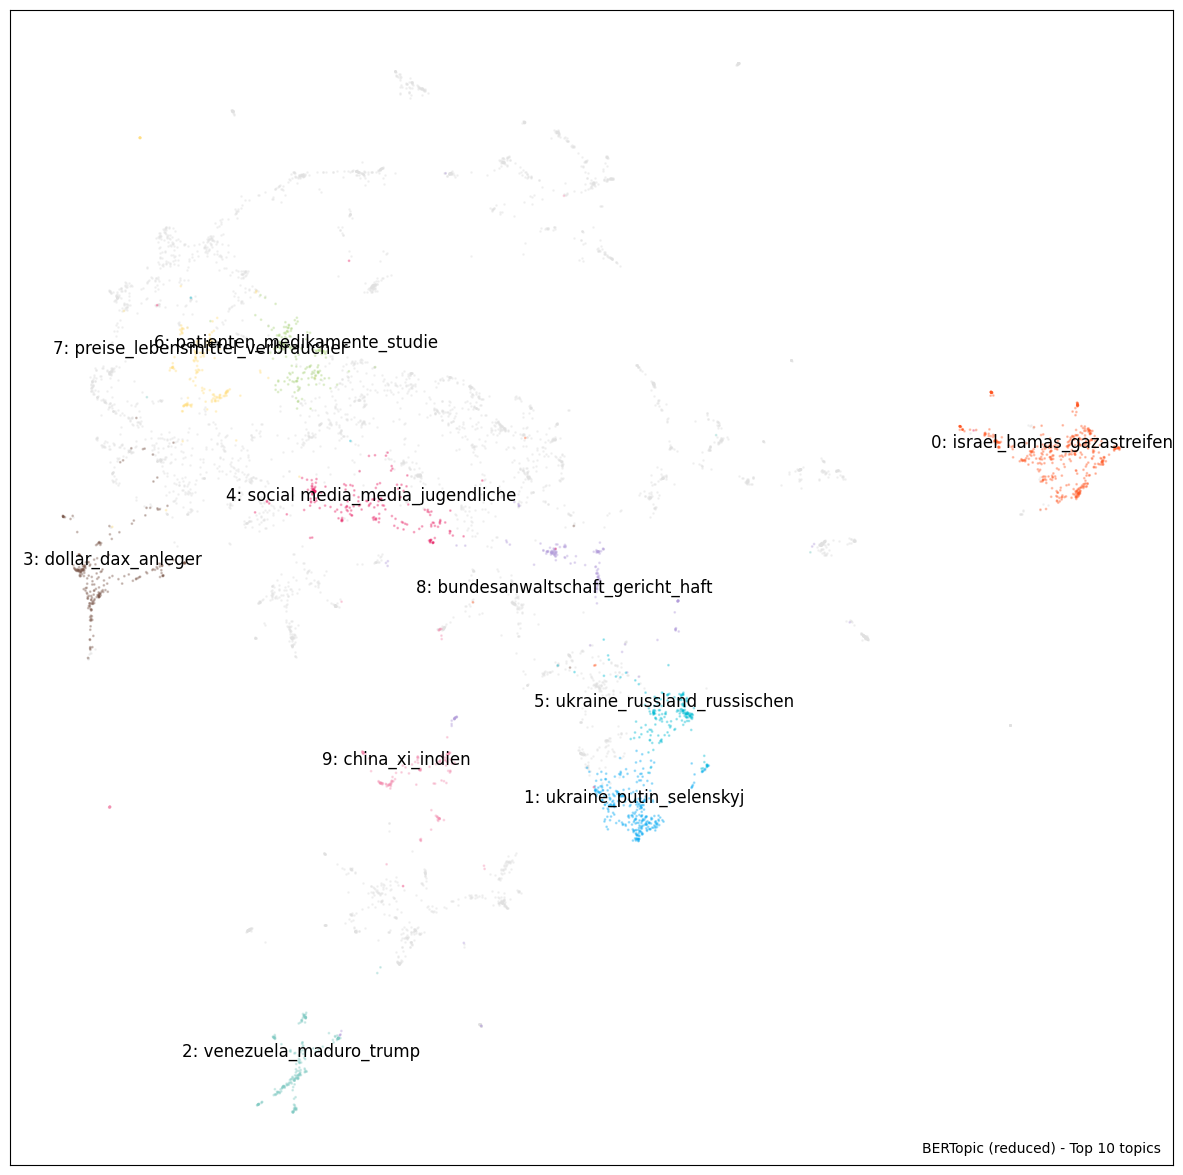

In [56]:
import numpy as np
import pandas as pd
from umap import UMAP
import matplotlib
import matplotlib.pyplot as plt

# Use existing reduced model/topics from the last code block (no new BERTopic fit).
topic_model_plot = topic_model_ctfidf_threshold
docs_plot = docs
topics_plot = list(new_topics_ctfidf_threshold)

# Prepare data for plotting
embeddings = topic_model_plot._extract_embeddings(docs_plot, method="document")
umap_model = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric="cosine").fit(embeddings)
df_plot = pd.DataFrame(umap_model.embedding_, columns=["x", "y"])
df_plot["topic"] = topics_plot

# Plot parameters
top_n = 10
fontsize = 12

# Keep top_n non-outlier topics by frequency; collapse others to -1 for readability
topic_info_plot = topic_model_plot.get_topic_info()
top_topic_ids = topic_info_plot[topic_info_plot["Topic"] != -1].nlargest(top_n, "Count")["Topic"].tolist()

to_plot = df_plot.copy()
to_plot.loc[~to_plot["topic"].isin(top_topic_ids), "topic"] = -1
outliers = to_plot.loc[to_plot["topic"] == -1]
non_outliers = to_plot.loc[to_plot["topic"] != -1]

# Visualize topics
cmap = matplotlib.colors.ListedColormap([
    "#FF5722", "#03A9F4", "#4CAF50", "#80CBC4", "#673AB7",
    "#795548", "#E91E63", "#212121", "#00BCD4", "#CDDC39",
    "#AED581", "#FFE082", "#BCAAA4", "#B39DDB", "#F48FB1",
])

fig, ax = plt.subplots(figsize=(15, 15))
ax.scatter(outliers["x"], outliers["y"], c="#E0E0E0", s=1, alpha=0.3)
ax.scatter(non_outliers["x"], non_outliers["y"], c=non_outliers["topic"], s=1, alpha=0.3, cmap=cmap)

# Add topic names to cluster centroids
centroids = non_outliers.groupby("topic", as_index=False)[["x", "y"]].mean()
for _, row in centroids.iterrows():
    topic = int(row["topic"])
    words = topic_model_plot.get_topic(topic) or []
    text = f"{topic}: " + "_".join([w for w, _ in words[:3]])
    ax.text(row["x"], row["y"] * 1.01, text, fontsize=fontsize, horizontalalignment="center")

ax.text(0.99, 0.01, f"BERTopic (reduced) - Top {top_n} topics", transform=ax.transAxes, horizontalalignment="right", color="black")
plt.xticks([], [])
plt.yticks([], [])
plt.show()

### Attach reduced topics to df_clean

Map the final c-TF-IDF-threshold topic assignments back to `df_clean` and display a clickable URL overview.


In [59]:
import pandas as pd
from IPython.display import display

base_result = result_ts_base if "result_ts_base" in globals() else (result_ts if "result_ts" in globals() else result)
prepared = base_result["prepared_documents"].copy()

if len(prepared) != len(new_topics_ctfidf_threshold):
    raise ValueError("Length mismatch between prepared docs and reduced topics.")

prepared["Topic_reduced_ctfidf_0_1"] = list(new_topics_ctfidf_threshold)

topic_name_map = (
    topic_model_ctfidf_threshold.get_topic_info()[["Topic", "Name"]]
    .drop_duplicates(subset=["Topic"])
    .set_index("Topic")["Name"]
    .to_dict()
)

prepared["Topic_Name_reduced_ctfidf_0_1"] = prepared["Topic_reduced_ctfidf_0_1"].map(topic_name_map)

# Attach topic classification to all rows in df_clean via original index mapping.
df_clean_topics_ctfidf_threshold = (
    df_clean.reset_index()
    .rename(columns={"index": "original_index"})
    .merge(
        prepared[["original_index", "Topic_reduced_ctfidf_0_1", "Topic_Name_reduced_ctfidf_0_1"]],
        on="original_index",
        how="left",
    )
)

url_col = next((c for c in ["URL", "Url", "url", "link"] if c in df_clean_topics_ctfidf_threshold.columns), None)

show_cols = [
    c for c in ["day", "title", "Topic_reduced_ctfidf_0_1", "Topic_Name_reduced_ctfidf_0_1", url_col]
    if c and c in df_clean_topics_ctfidf_threshold.columns
]

if url_col is not None:
    display(
        df_clean_topics_ctfidf_threshold[show_cols]
        .head(100)
        .style.format({
            url_col: lambda x: f'<a href="{x}" target="_blank">{x}</a>' if pd.notna(x) else ""
        })
    )
else:
    display(df_clean_topics_ctfidf_threshold[show_cols].head(100))

print(f"Rows in df_clean_topics_ctfidf_threshold: {len(df_clean_topics_ctfidf_threshold):,}")

,Topic_reduced_ctfidf_0_1,Topic_Name_reduced_ctfidf_0_1,URL
0,25.000000,25_taliban_afghanistan_pakistan_afghanen,https://www.tagesschau.de/api2u/afghanistan-flieger-pakistan-100.json?view=hasChanged&lastKnown=0E5CAD014B3854E66D9485139AB49AB9
1,25.000000,25_taliban_afghanistan_pakistan_afghanen,https://www.tagesschau.de/api2u/afghanistan-internet-104.json?view=hasChanged&lastKnown=F0C62FADA4B1BC09BDFE42049ACABD61
2,-1.000000,-1_papst_afd_kirche_leo,https://www.tagesschau.de/api2u/aethiopien-deutsche-welle-korrespondenten-100.json?view=hasChanged&lastKnown=183183B65898ACFAFDE89020F32C94E2
3,15.000000,15_überschwemmungen_ums leben_ums_philippinen,https://www.tagesschau.de/api2u/aethiopien-kirche-einsturz-100.json?view=hasChanged&lastKnown=D12B134A79E4318A21FA4D06203E5B97
4,51.000000,51_china_exporte_erden_chinas,https://www.tagesschau.de/api2u/agoa-usa-afrika-100.json?view=hasChanged&lastKnown=11A5CB30EAD003D5DDEB87D54F2FD002
5,nan,nan,https://www.tagesschau.de/api2u/alaa-abdel-fattah-freilassung-100.json?view=hasChanged&lastKnown=89003A3FA7FA6E752DC1960A06B0D518
6,-1.000000,-1_papst_afd_kirche_leo,https://www.tagesschau.de/api2u/bootsunglueck-mauretanien-migranten-100.json?view=hasChanged&lastKnown=55DD38CCEDA562A5BF039244C070354E
7,-1.000000,-1_papst_afd_kirche_leo,https://www.tagesschau.de/api2u/bootsunglueck-tunesien-104.json?view=hasChanged&lastKnown=FB8ED3475004BEA9A5E49A6D3CEB611E
8,6.000000,6_patienten_medikamente_studie_erkrankungen,https://www.tagesschau.de/api2u/botswana-gesundheitskrise-100.json?view=hasChanged&lastKnown=280E341E3C68CE86C2A0405DA42371EF
9,6.000000,6_patienten_medikamente_studie_erkrankungen,https://www.tagesschau.de/api2u/cholera-ausbruch-afrika-100.json?view=hasChanged&lastKnown=203EBF22709292FBB30550D11588061D


Rows in df_clean_topics_ctfidf_threshold: 6,320
